In [1]:

import astropy.units as u
import gizmo_analysis as gizmo
import matplotlib.pyplot as plt
import numpy as np
from astropy.cosmology import Planck18 as cosmo

%config InlineBackend.figure_format = 'retina'

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [2]:
redshift = 0.1
sim_dir = "/mnt/ceph/users/firesims/fire2/public_release/core/m12i_res7100/"
part = gizmo.io.Read.read_snapshots(
    ["dark", "star", "gas"], "redshift", redshift, sim_dir, snapshot_directory="output"
)


# in utilities.simulation.Snapshot():
* reading:  mnt/ceph/users/firesims/fire2/public_release/core/m12i_res7100/snapshot_times.txt

* input redshift = 0.1:  using snapshot index = 534, redshift = 0.100


# in gizmo_analysis.gizmo_io.Read():
* reading header from:  mnt/ceph/users/firesims/fire2/public_release/core/m12i_res7100/output/snapdir_534/snapshot_534.0.hdf5
  snapshot contains the following number of particles:
    dark      (id = 1): 70514272 particles
    dark2     (id = 2): 5513331 particles
    gas       (id = 0): 57969288 particles
    star      (id = 4): 12974577 particles
    blackhole (id = 5): 0 particles

* reading the following
  species: ['dark', 'star', 'gas']

* reading particles from:
    snapshot_534.0.hdf5
    snapshot_534.1.hdf5
    snapshot_534.2.hdf5
    snapshot_534.3.hdf5

* reading cosmological parameters from:  mnt/ceph/users/firesims/fire2/public_release/core/m12i_res7100/initial_condition/ic_agora_m12i.conf

* checking sanity of particle properties




In [3]:
import matplotlib as mpl

In [4]:
star_pos = part["star"].prop("host.distance.principal")
star_mass = np.array(part["star"]["mass"])

In [ ]:
R = np.sqrt(star_pos[:, 0]**2 + star_pos[:, 1]**2)
z = star_pos[:, 2]

Rbins = np.linspace(1, 30, 100)
zbins = np.linspace(-5, 5, 101)
H, xe, ye = np.histogram2d(R, z, bins=(Rbins, zbins), weights=star_mass)
Rbinc = 0.5 * (Rbins[1:] + Rbins[:-1])
zbinc = 0.5 * (zbins[1:] + zbins[:-1])

# volume factor
V = 2 * np.pi * (Rbins[1:]**2 - Rbins[:-1]**2)[:, None] * (zbins[1:] - zbins[:-1])[None, :]

# adjust density by volume
dens = H / V

In [13]:
import gala.potential as gp

In [16]:
gp.MilkyWayPotential(version='v2')["disk"]

<MN3ExponentialDiskPotential: m=4.77e+10 solMass, h_R=2.60 kpc, h_z=0.30 kpc (kpc,Myr,solMass,rad)>

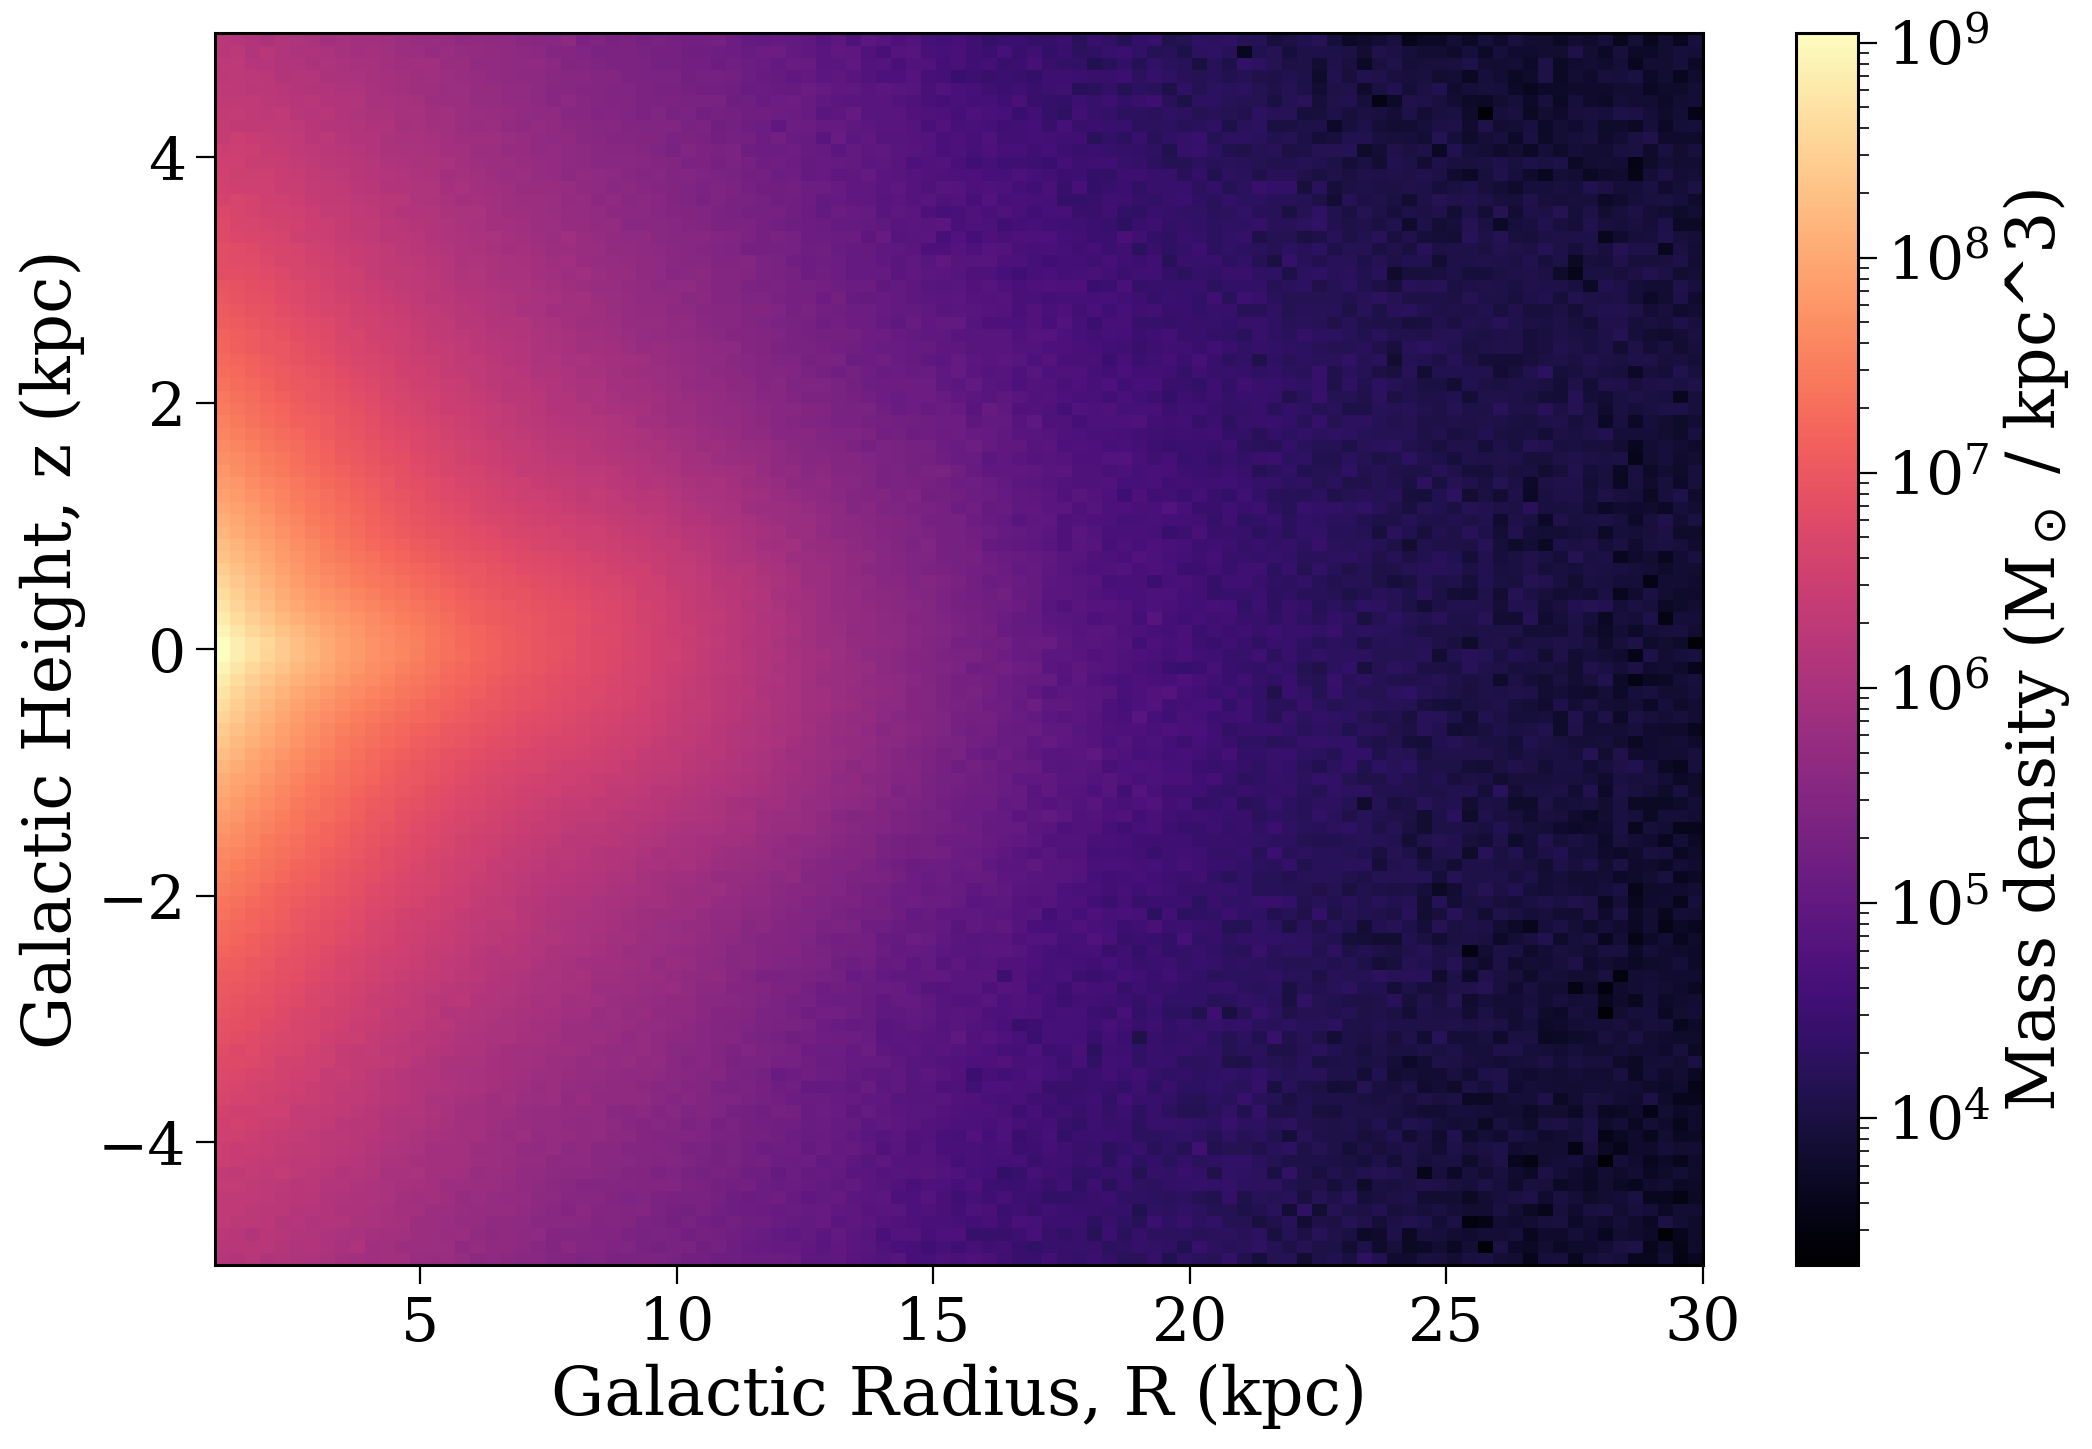

In [10]:
fig, ax = plt.subplots()

ax.pcolormesh(xe, ye, dens.T, norm=mpl.colors.LogNorm(), cmap='magma')
fig.colorbar(ax.collections[0], label="Mass density (M$_\odot$ / kpc^3)")

ax.set(
    xlabel='Galactic Radius, R (kpc)',
    ylabel='Galactic Height, z (kpc)',
)

plt.show()

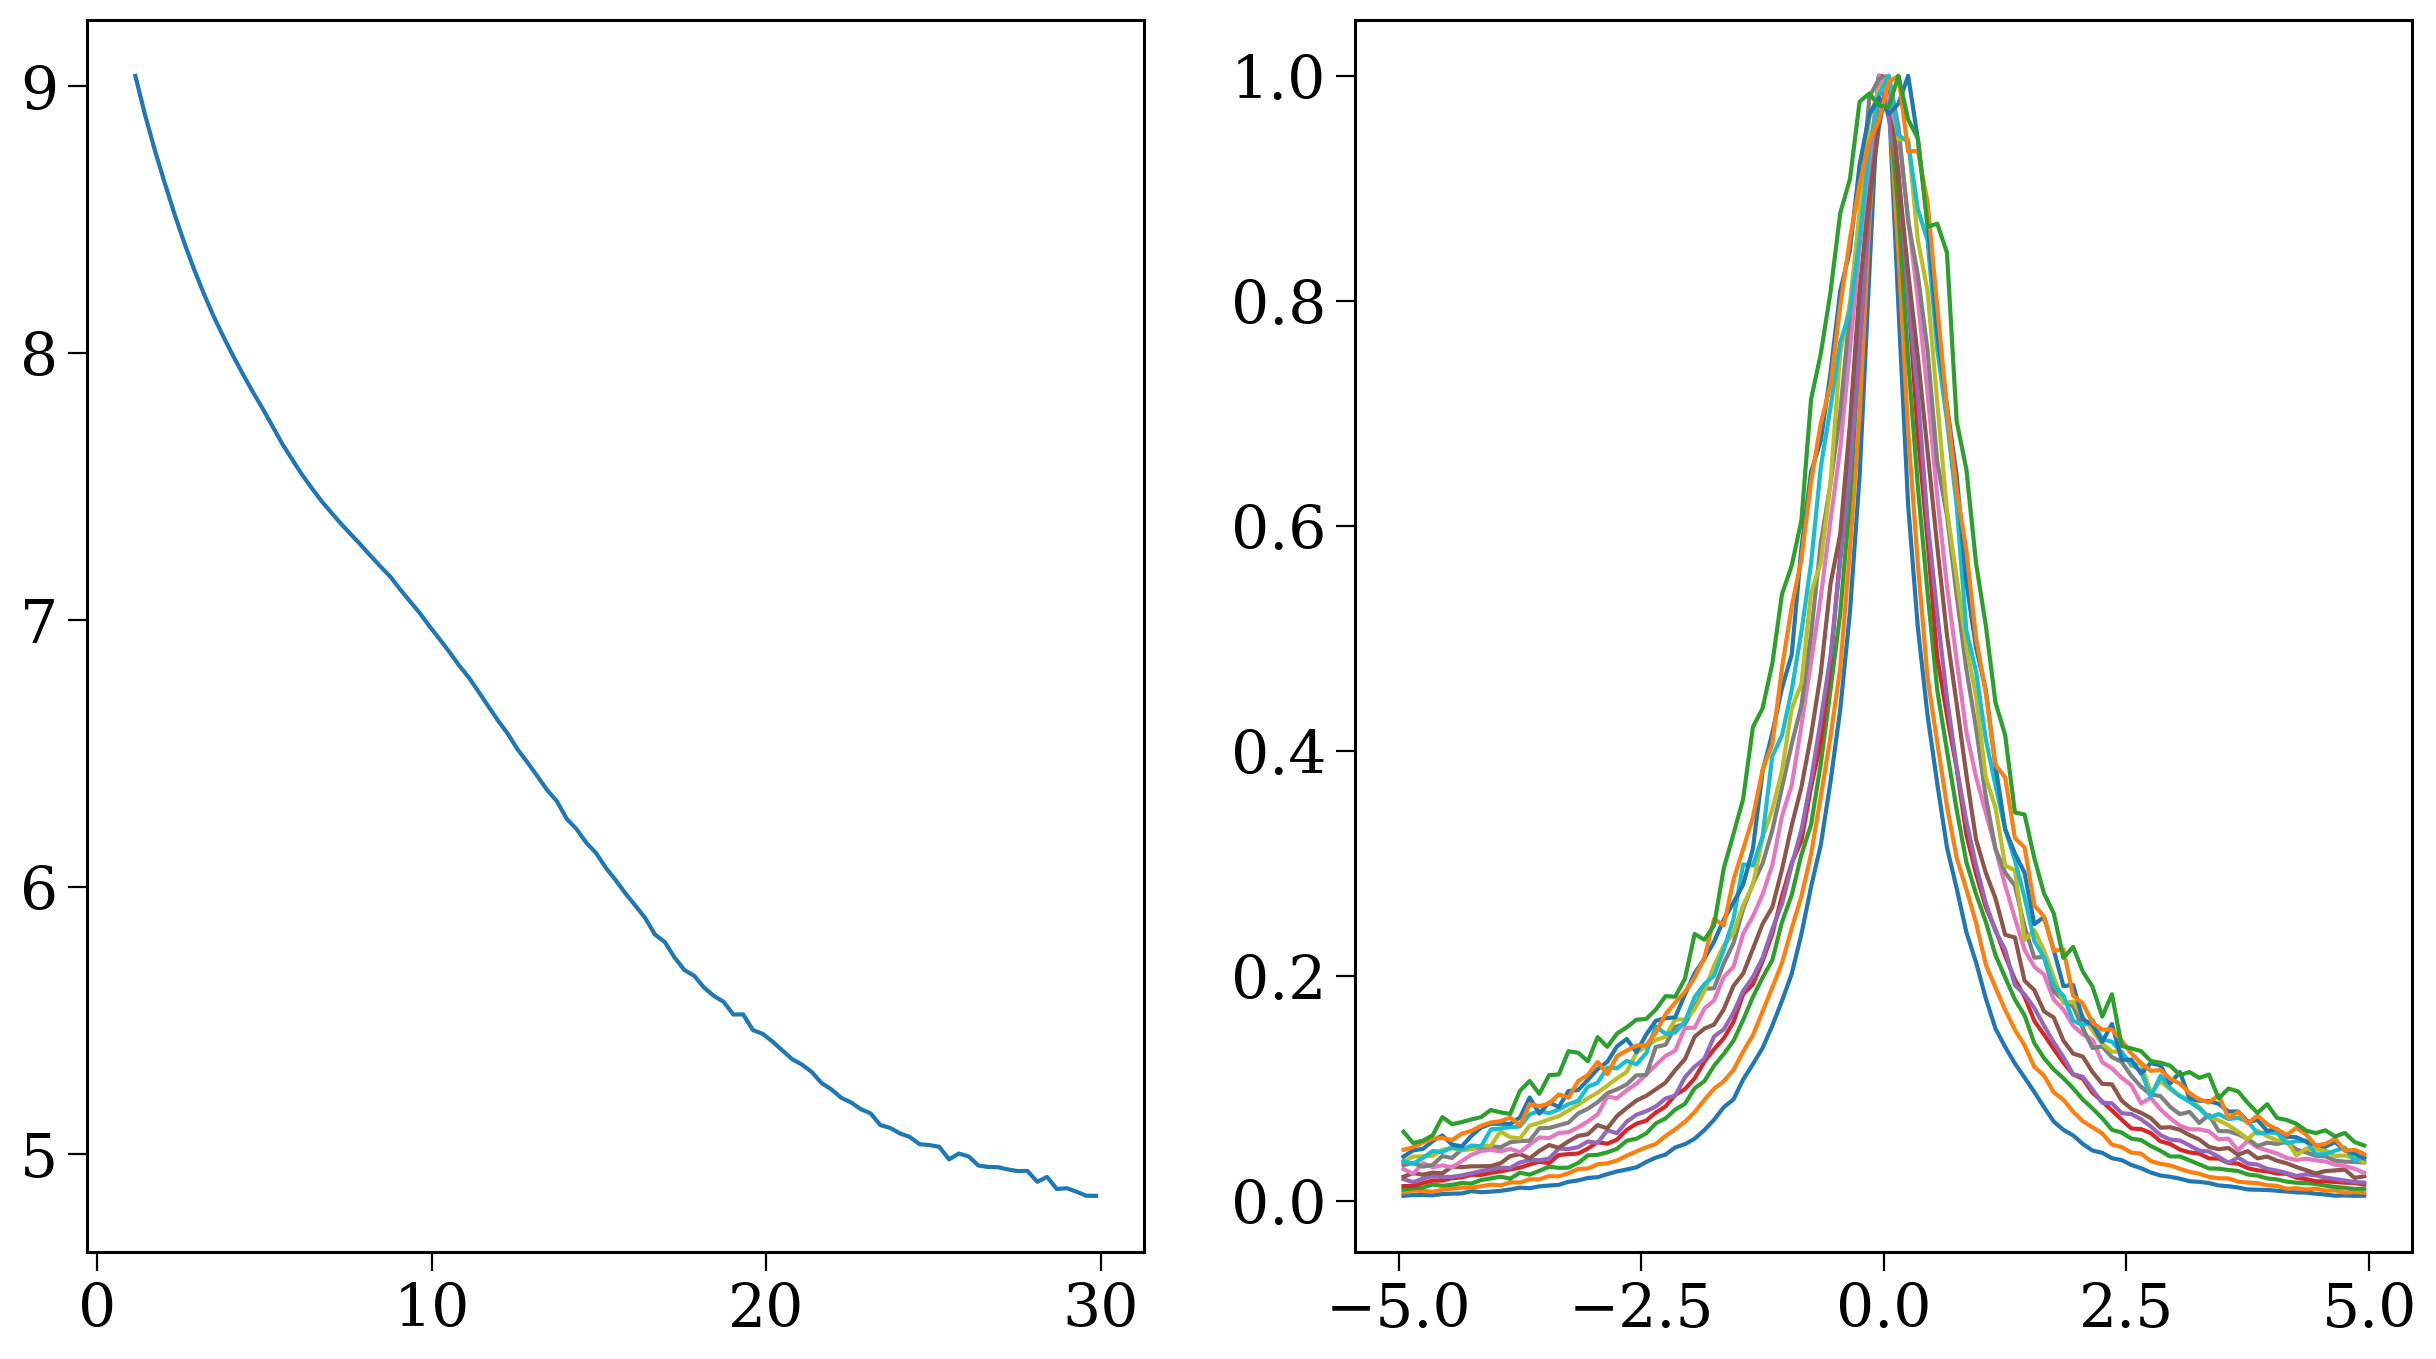

In [32]:
surf_mass_R = np.sum(dens, axis=1) * (ye[1] - ye[0])

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
axes[0].plot(Rbinc, np.log10(surf_mass_R))
# axes[0].set_yscale("log")

# axes[1].plot(zbinc, dens[8:50:2].T, marker="")``
for line in dens[4:30:2]:
    axes[1].plot(zbinc, line / line.max(), marker="")

In [43]:
redshifts = np.linspace(0, 3, 31)
times = cosmo.age(redshifts).value  # in Gyr
base_path = "/mnt/ceph/users/twagg/underworld/mass_growth/m12i_alt/"

radii = np.load(f"{base_path}/z_{0.00:.2f}.npz", allow_pickle=True)["radii"]

M_encs = np.array([np.load(f"{base_path}/z_{z:.2f}.npz", allow_pickle=True)["dm_M_enc"] for z in redshifts])
M_encs_baryon = np.array([np.load(f"{base_path}/z_{z:.2f}.npz", allow_pickle=True)["baryon_M_enc"] for z in redshifts])

densities = np.array([np.load(f"{base_path}/z_{z:.2f}.npz", allow_pickle=True)["dens"] for z in redshifts])
xe = np.load(f"{base_path}/z_{0.00:.2f}.npz", allow_pickle=True)["xe"]
ye = np.load(f"{base_path}/z_{0.00:.2f}.npz", allow_pickle=True)["ye"]
Rbinc = 0.5 * (xe[1:] + xe[:-1])
zbinc = 0.5 * (ye[1:] + ye[:-1])

colours = plt.cm.viridis(np.linspace(0, 1, len(redshifts)))

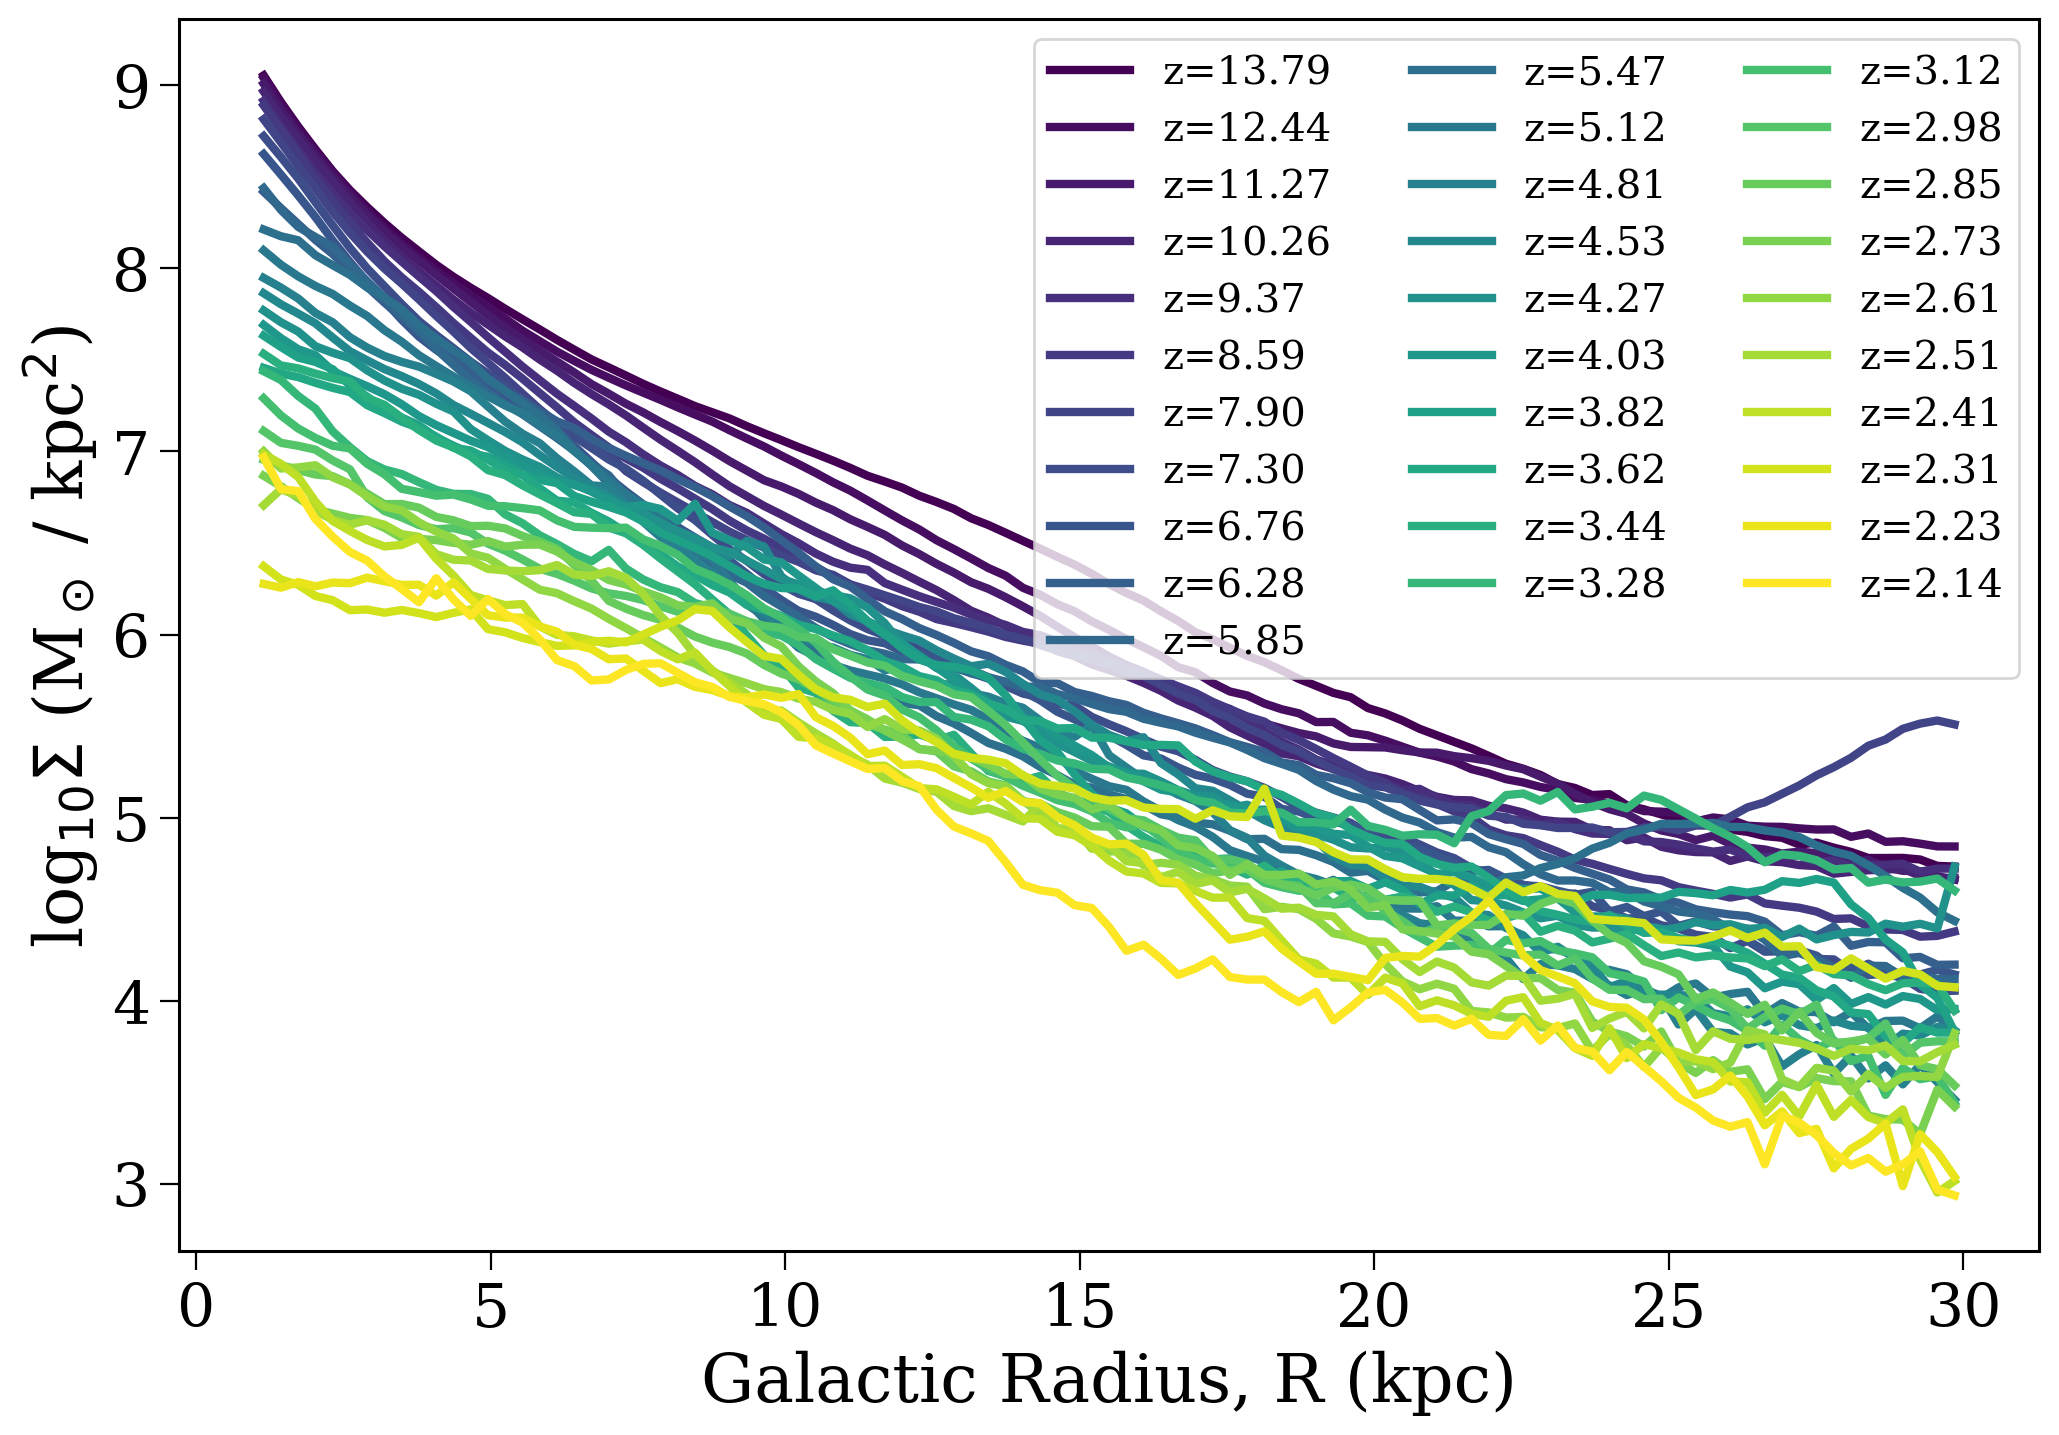

In [48]:
fig, ax = plt.subplots()

for i in range(0, len(redshifts)):
    surf_mass_R = np.sum(densities[i], axis=1) * (ye[1] - ye[0])
    ax.plot(Rbinc, np.log10(surf_mass_R), label=f"z={times[i]:.2f}", color=colours[i], lw=3)

ax.set(
    xlabel="Galactic Radius, R (kpc)",
    ylabel="log$_{10} \Sigma$ (M$_\odot$ / kpc$^2$)",
)

ax.legend(ncol=3, fontsize=0.6*fs)

plt.show()

In [55]:
M_encs[:, 4]

array([3.0218027e+11, 3.0212057e+11, 2.9563168e+11, 2.9133790e+11,
       2.7409891e+11, 2.7480266e+11, 2.8698889e+11, 2.6200257e+11,
       2.6075336e+11, 2.5171362e+11, 2.6710963e+11, 2.7760538e+11,
       2.7554002e+11, 2.6731618e+11, 2.3683809e+11, 2.0161436e+11,
       2.0493556e+11, 2.0904829e+11, 2.0673813e+11, 2.0630330e+11,
       2.0896784e+11, 2.0118087e+11, 1.8476309e+11, 1.6773387e+11,
       1.4710840e+11, 1.3882606e+11, 1.3886928e+11, 1.4068033e+11,
       1.4445250e+11, 1.4561785e+11, 1.4550765e+11], dtype=float32)

In [54]:
radii

array([  1,  10,  20,  30,  50, 100, 200, 300])

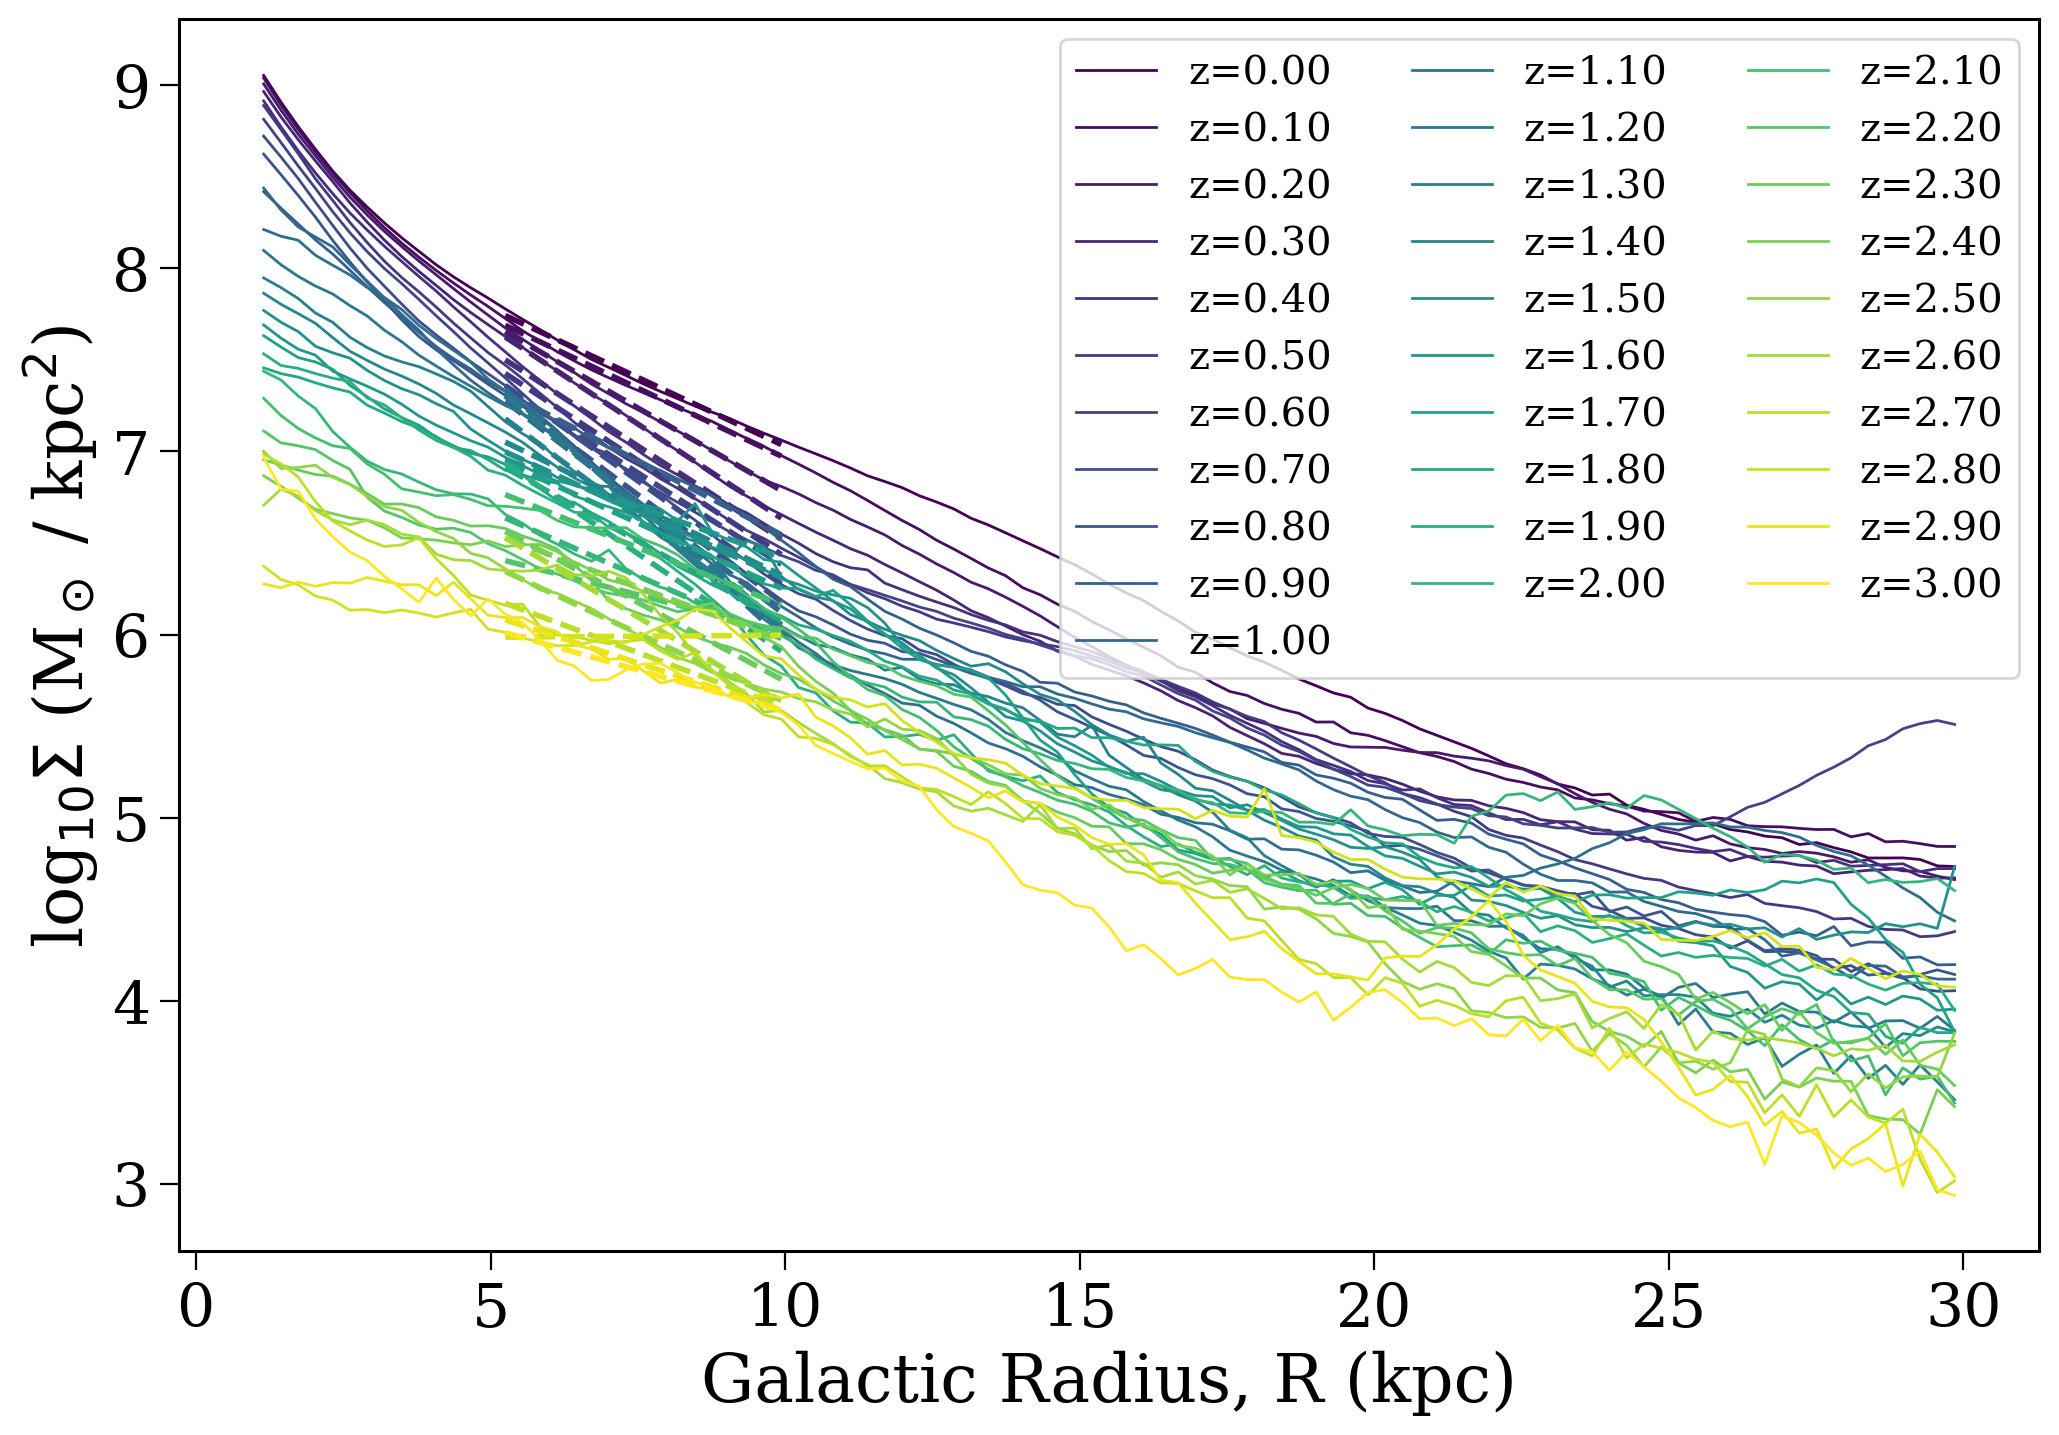

In [74]:
fig, ax = plt.subplots()

slopes = np.zeros(len(redshifts))

for i in range(0, len(redshifts)):
    surf_mass_R = np.sum(densities[i], axis=1) * (ye[1] - ye[0])
    ax.plot(Rbinc, np.log10(surf_mass_R), label=f"z={redshifts[i]:.2f}", color=colours[i], lw=1)

    # fit a linear line to surf_mass_R in the range of 5 to 15 kpc
    mask = (Rbinc >= 5) & (Rbinc <= 10)
    coeffs = np.polyfit(Rbinc[mask], np.log10(surf_mass_R[mask]), 1)
    fit_line = np.poly1d(coeffs)(Rbinc[mask])
    ax.plot(Rbinc[mask], fit_line, linestyle='--', color=colours[i], lw=2)

    slopes[i] = coeffs[0]

ax.set(
    xlabel="Galactic Radius, R (kpc)",
    ylabel="log$_{10} \Sigma$ (M$_\odot$ / kpc$^2$)",
)

ax.legend(ncol=3, fontsize=0.6*fs)

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


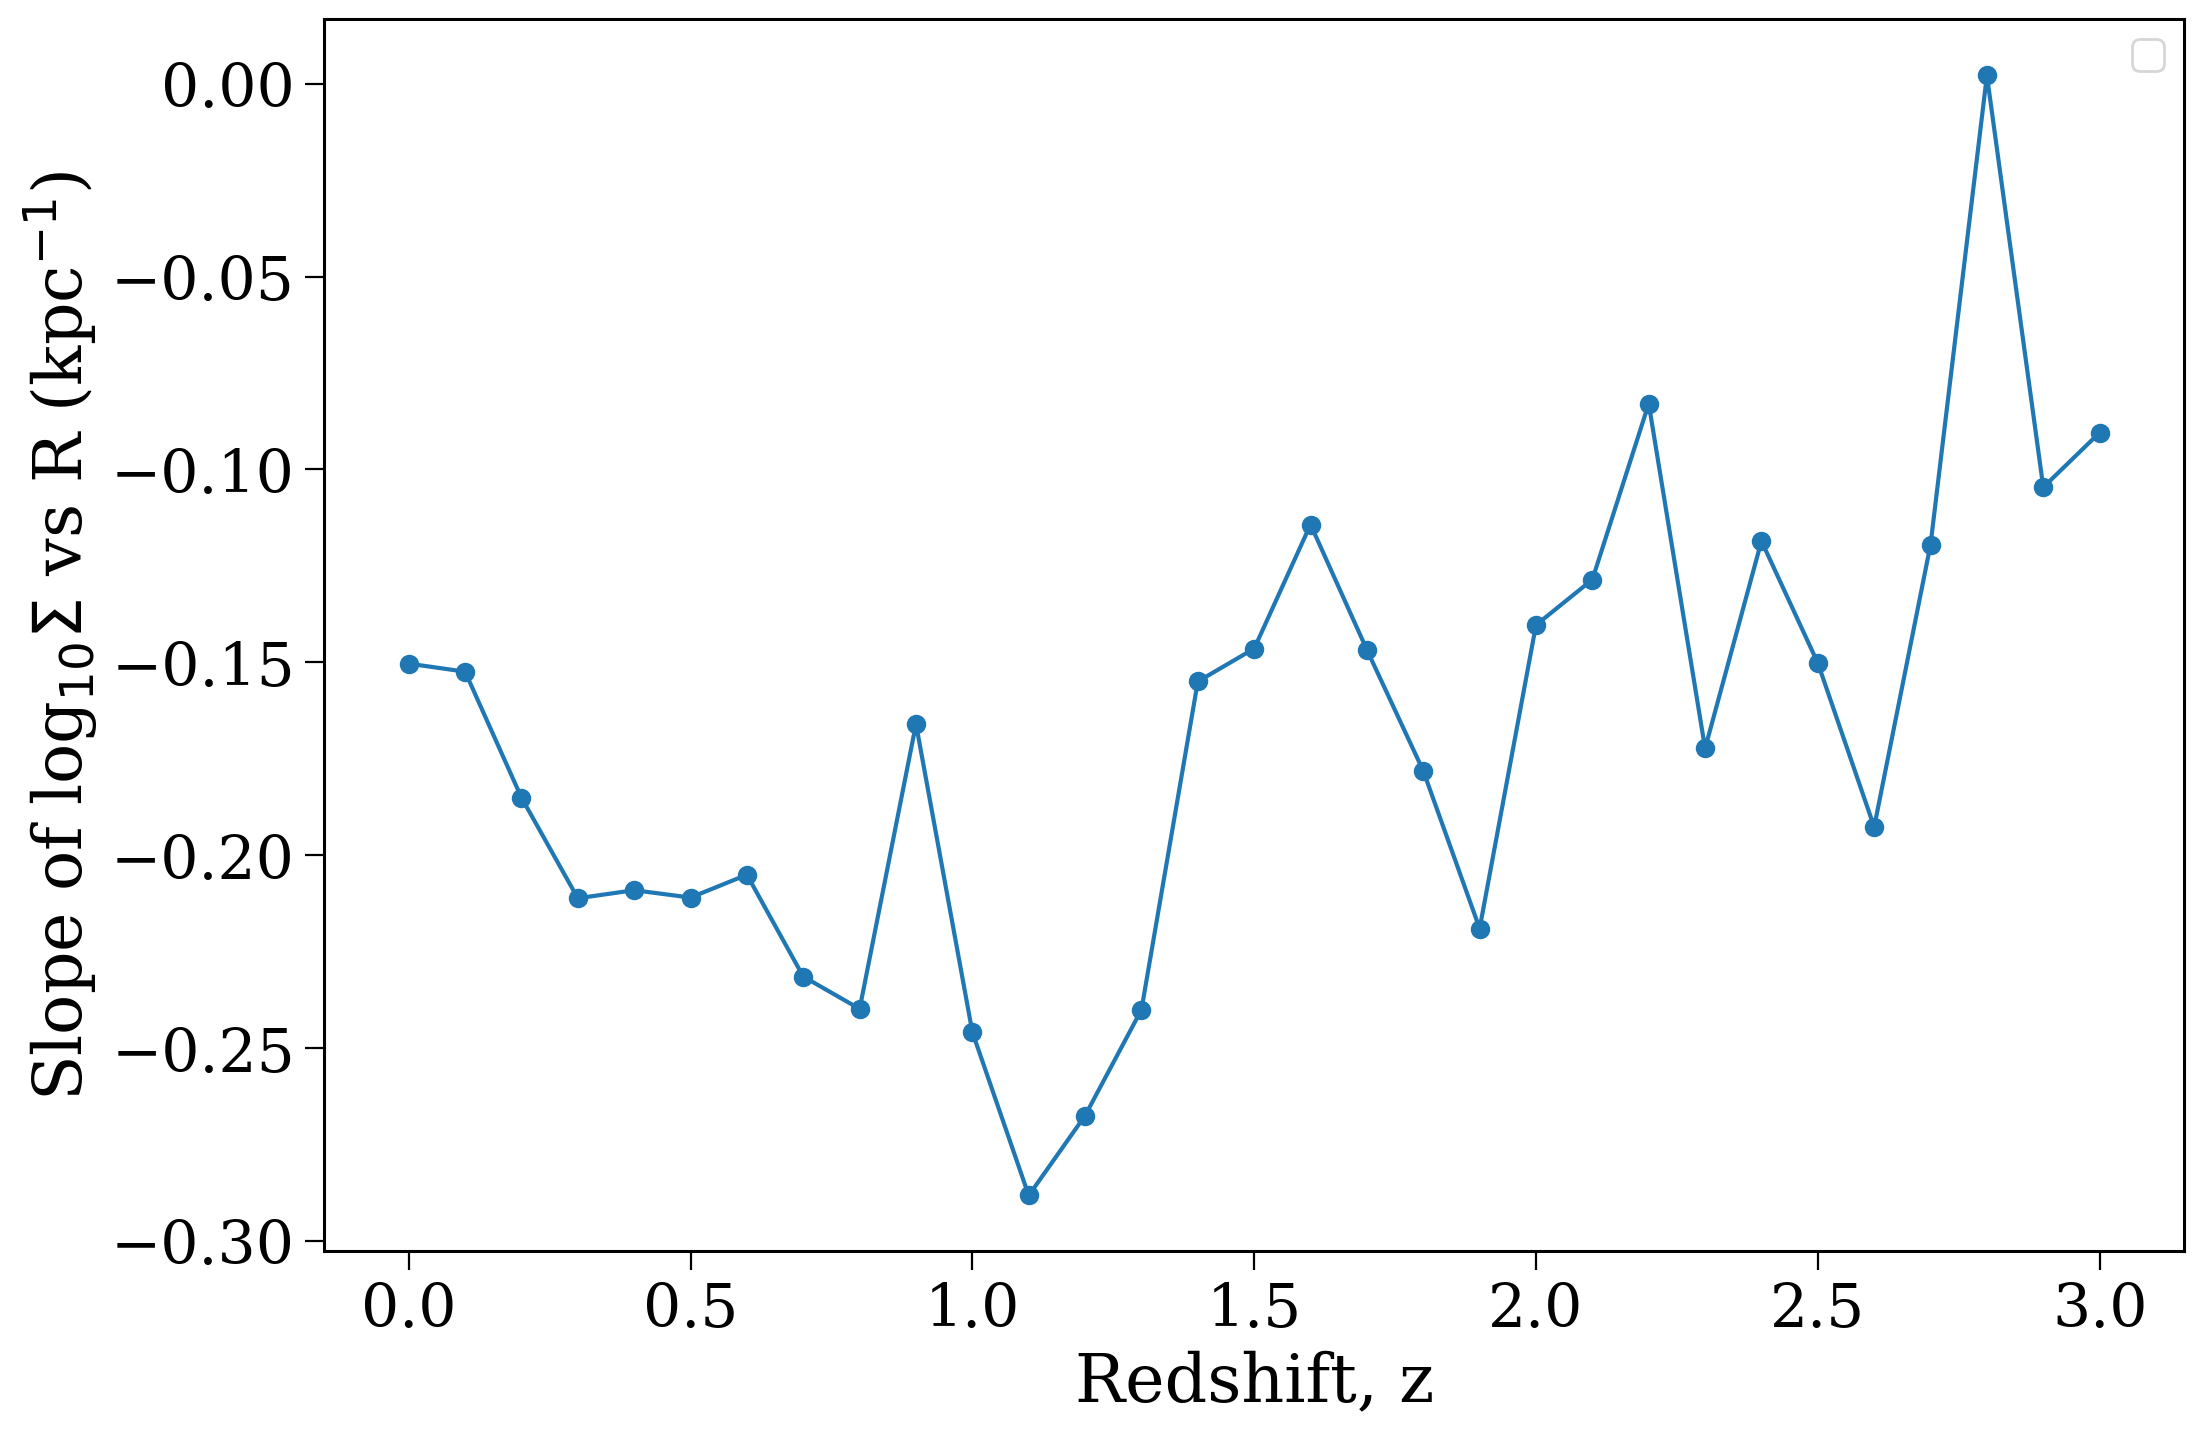

In [75]:
fig, ax = plt.subplots()

ax.plot(redshifts, slopes, marker='o')

ax.legend(ncol=3, fontsize=0.6*fs)

ax.set(
    xlabel="Redshift, z",
    ylabel="Slope of log$_{10} \Sigma$ vs R (kpc$^{-1}$)",
)

plt.show()

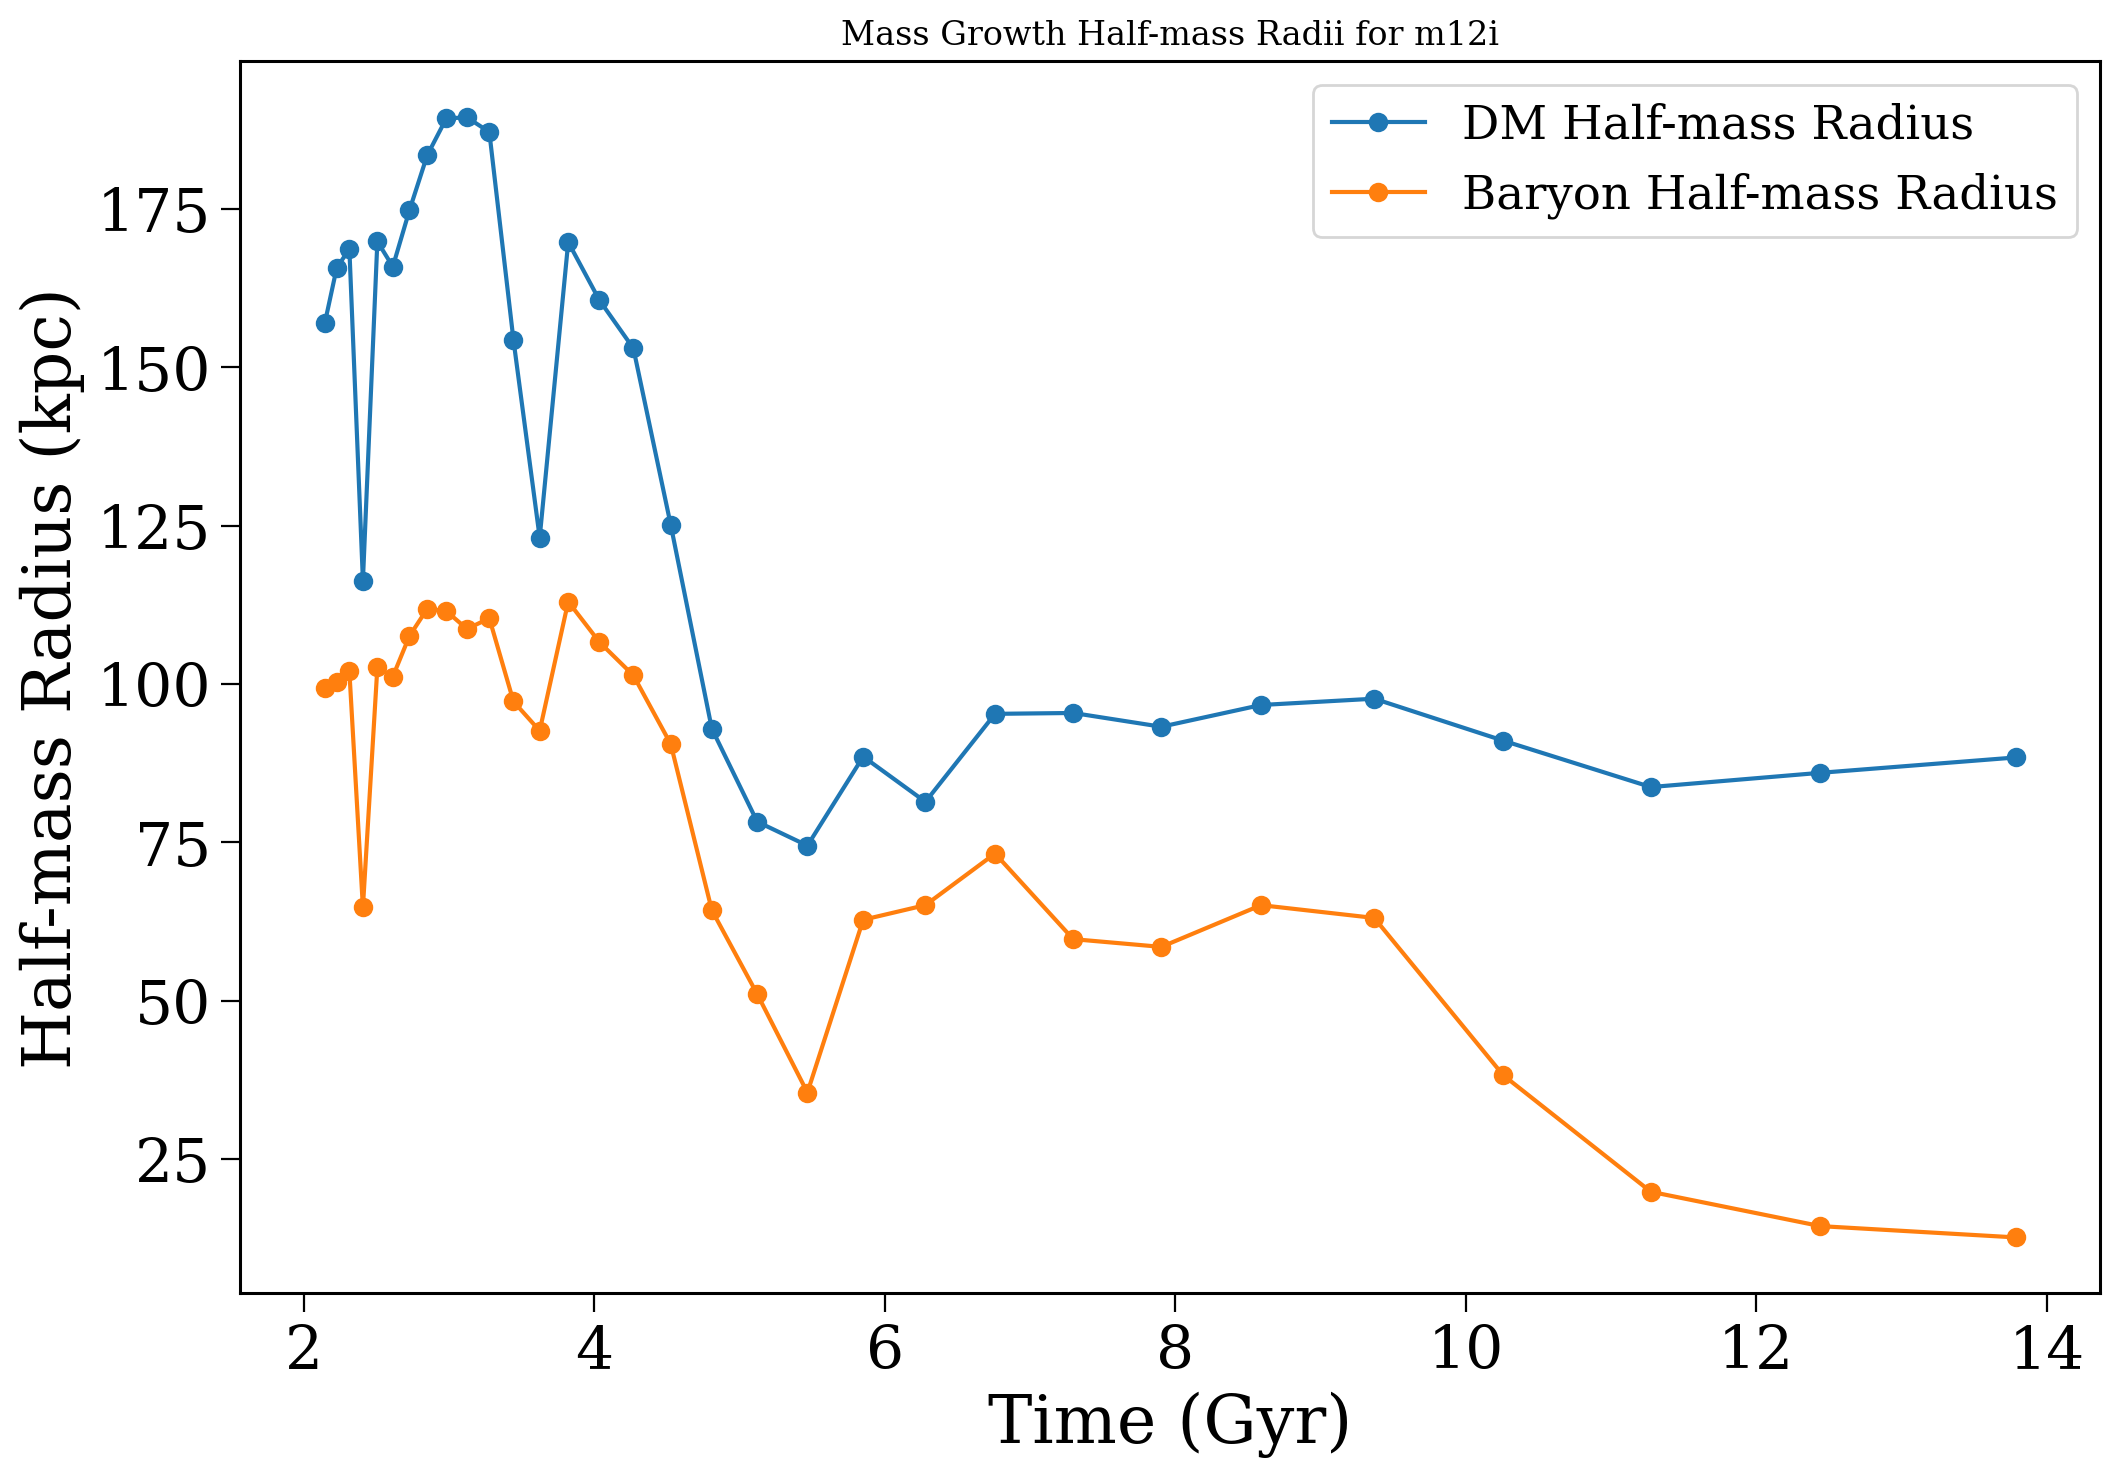

In [14]:
plt.plot(times, dm_R_half, marker='o', label="DM Half-mass Radius")
plt.plot(times, baryon_R_half, marker='o', label="Baryon Half-mass Radius")
plt.xlabel("Time (Gyr)")
plt.ylabel("Half-mass Radius (kpc)")
plt.legend()
plt.title("Mass Growth Half-mass Radii for m12i")
plt.show()


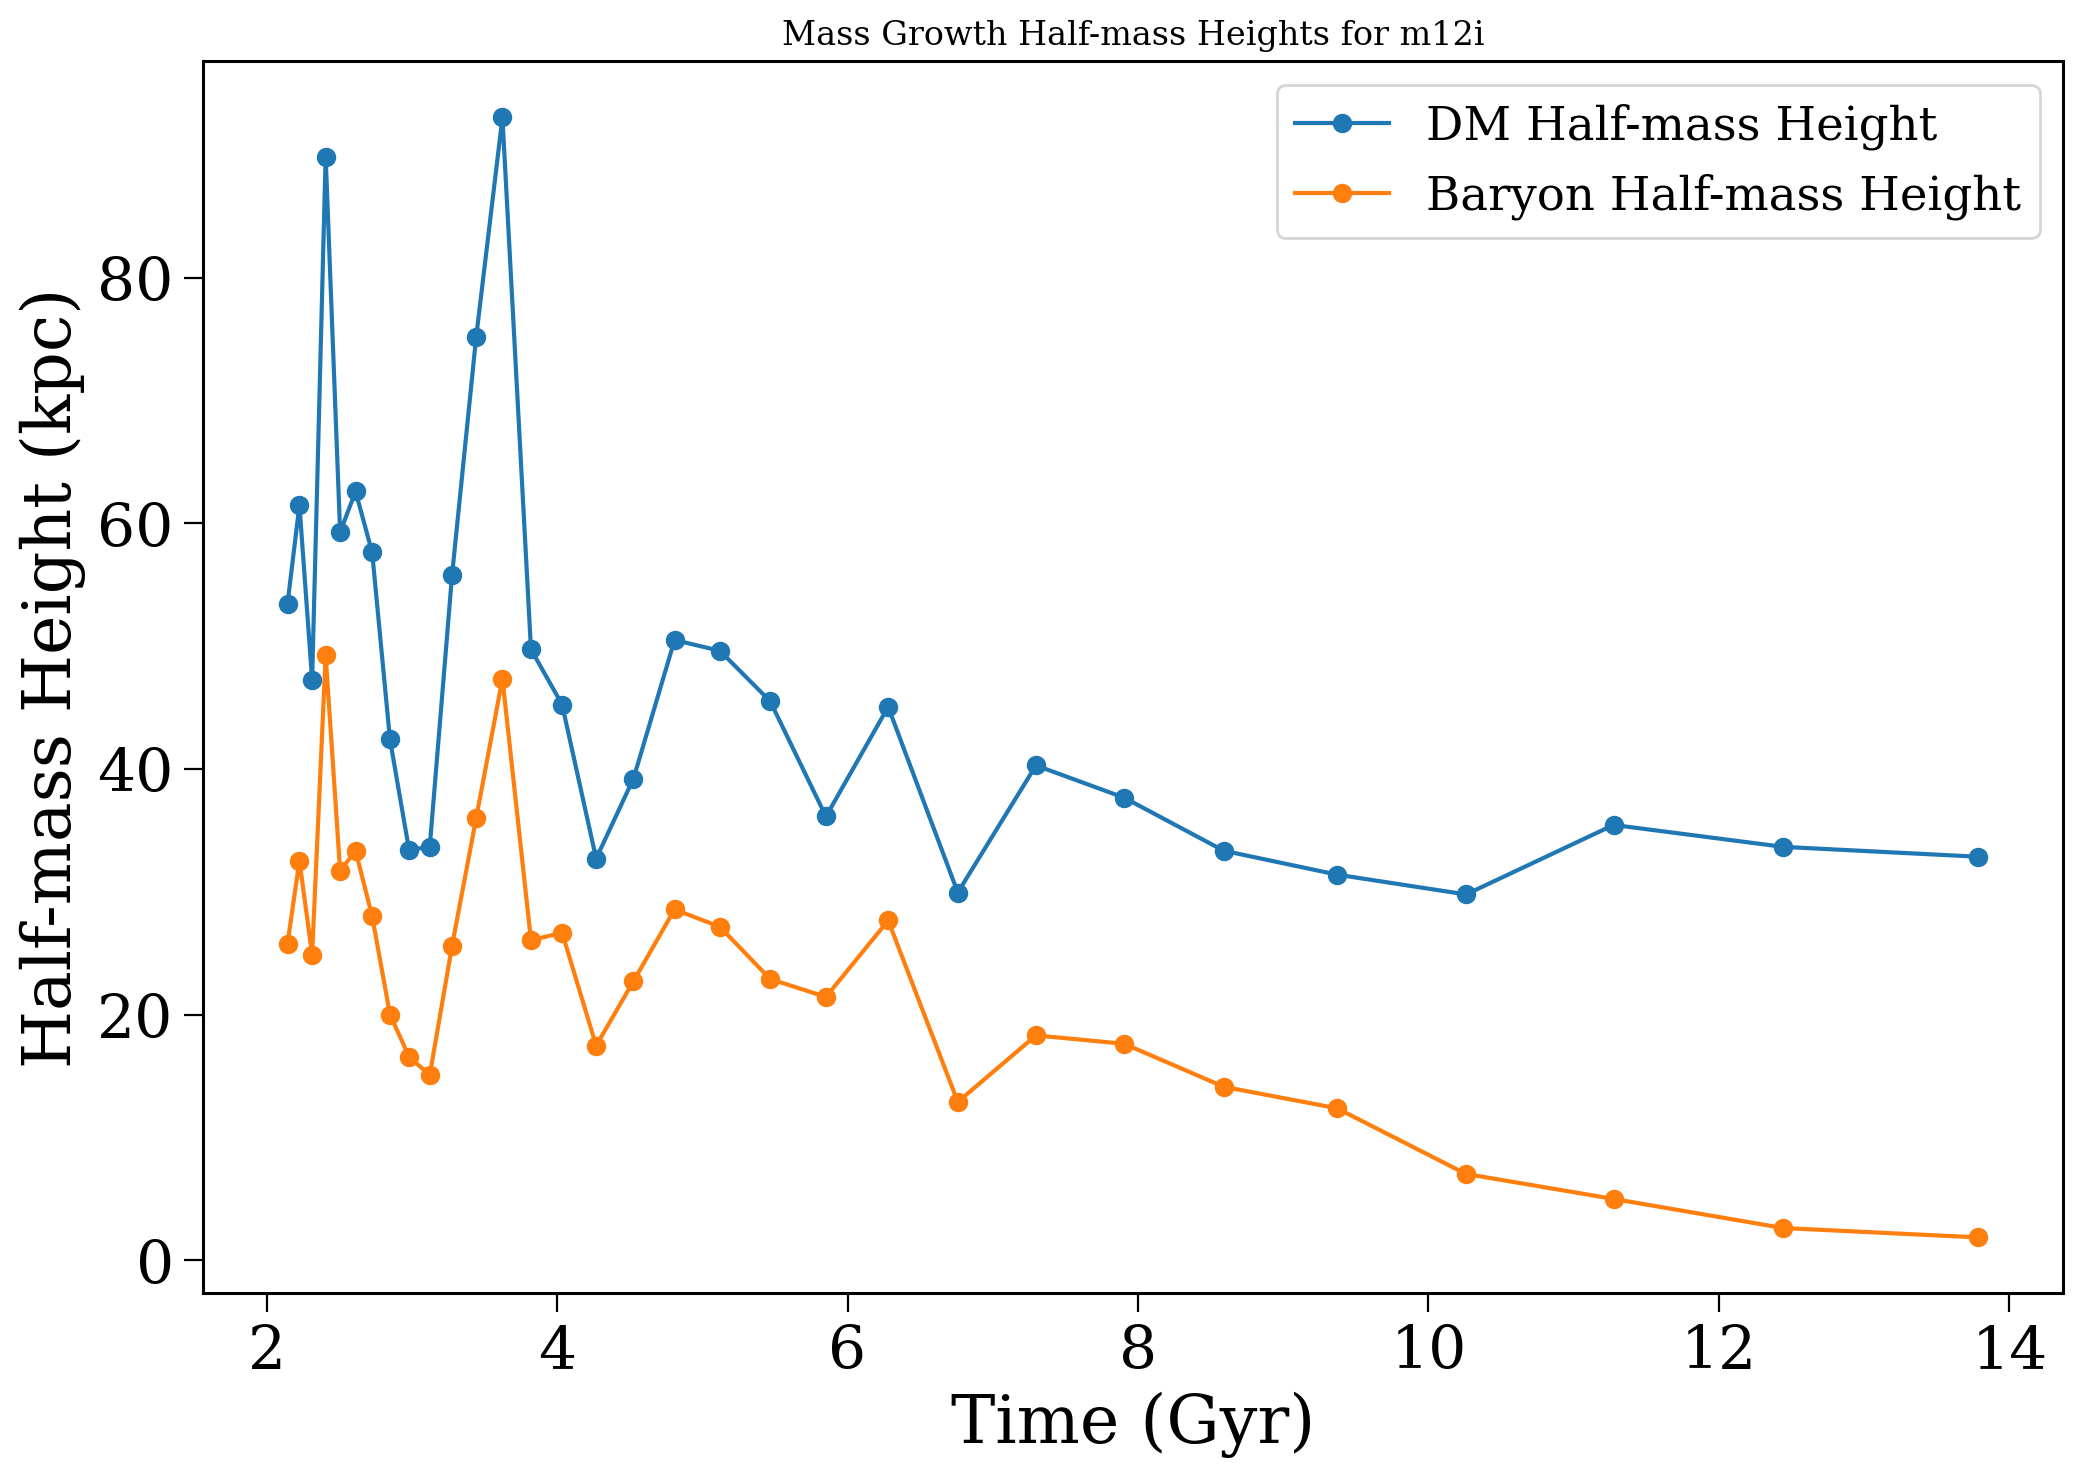

In [16]:
plt.plot(times, dm_z_half, marker='o', label="DM Half-mass Height")
plt.plot(times, baryon_z_half, marker='o', label="Baryon Half-mass Height")
plt.xlabel("Time (Gyr)")
plt.ylabel("Half-mass Height (kpc)")
plt.legend()
plt.title("Mass Growth Half-mass Heights for m12i")
plt.show()


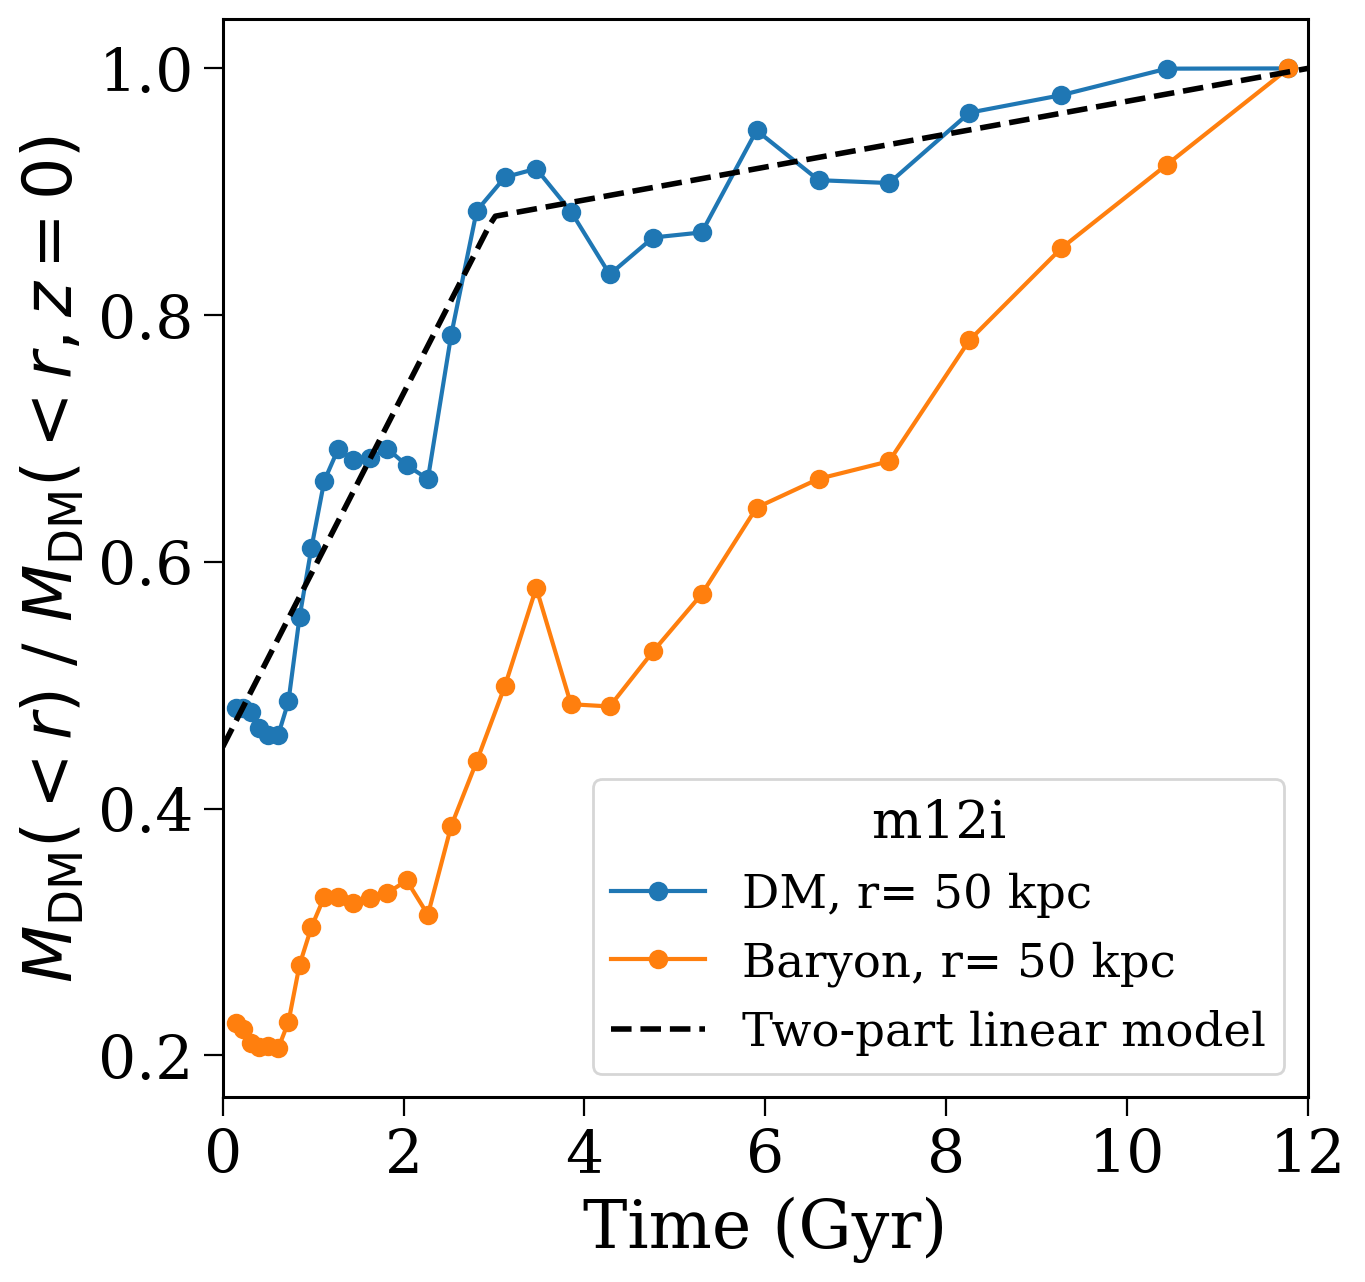

In [11]:
fig, ax = plt.subplots(figsize=(7, 7))

time_knots = np.linspace(0, 12, 200) * u.Gyr
mass_at_knot = np.zeros_like(time_knots.value) * u.Msun
for i, t in enumerate(time_knots.value):
    if t < 3:
        mass_at_knot[i] = (0.45 + (0.88 - 0.45) / 3 * t) * u.Msun
    else:
        mass_at_knot[i] = (0.88 + (1.0 - 0.88) / (12 - 3) * (t - 3)) * u.Msun

for r_idx, r in enumerate(radii):
    if r in [50]:
        ax.plot(times - 2, M_encs[:, r_idx] / M_encs[0, r_idx], marker='o', label=f"DM, r= {r:.0f} kpc")
        ax.plot(times - 2, M_encs_baryon[:, r_idx] / M_encs_baryon[0, r_idx], marker='o', label=f"Baryon, r= {r:.0f} kpc")

ax.plot(time_knots.value, mass_at_knot.value / mass_at_knot.value[-1], 'k--', label="Two-part linear model", lw=2)
ax.set(
    xlabel="Time (Gyr)",
    ylabel=r"$M_{\rm DM}(<r)$ / $M_{\rm DM}(<r, z=0)$",
    xlim=(0, 12)
)
ax.legend(title="m12i", loc='lower right')

plt.savefig("../plots/simple_mass_growth.pdf", format='pdf', bbox_inches='tight')

plt.show()

In [39]:
import gala.potential as gp

In [40]:
static_mw = gp.MilkyWayPotential(version='v2')

time_knots = np.linspace(0, 12, 20) * u.Gyr

# use y = mx + c
# t < 3.5 Gyr: linear from (0, 0.45) to (3.5, 0.88)
# t >= 3.5 Gyr: linear from (3.5, 0.88) to (12, 1.0)
mass_at_knot = np.zeros_like(time_knots.value) * u.Msun
for i, t in enumerate(time_knots.value):
    if t < 3.5:
        mass_at_knot[i] = (0.45 + (0.88 - 0.45) / 3.5 * t) * u.Msun
    else:
        mass_at_knot[i] = (0.88 + (1.0 - 0.88) / (12 - 3.5) * (t - 3.5)) * u.Msun
mass_at_knot *= static_mw["halo"].parameters["m"].value

In [43]:
mw["disk"]

<MN3ExponentialDiskPotential: m=4.77e+10 solMass, h_R=2.60 kpc, h_z=0.30 kpc (kpc,Myr,solMass,rad)>

In [44]:
mw["bulge"]

<HernquistPotential: m=5.00e+09 solMass, c=1.00 kpc (kpc,Myr,solMass,rad)>

In [45]:
mw["nucleus"]

<HernquistPotential: m=1.81e+09 solMass, c=0.07 kpc (kpc,Myr,solMass,rad)>

In [54]:
static_mw["halo"]

<NFWPotential: m=5.54e+11 solMass, r_s=15.63 kpc, a=1.00 , b=1.00 , c=1.00  (kpc,Myr,solMass,rad)>

In [46]:
evolving_mw = gp.CCompositePotential(
    disk=gp.MN3ExponentialDiskPotential(
        m=4.77e10 * u.Msun,
        h_R=2.6 * u.kpc,
        h_z=0.3 * u.kpc,
        units="galactic"
    ),
    bulge=gp.HernquistPotential(
        m=5e9 * u.Msun,
        c=1.0 * u.kpc,
        units="galactic"
    ),
    nucleus=gp.HernquistPotential(
        m=1.81e9 * u.Msun,
        c=0.07 * u.kpc,
        units="galactic"
    ),
    halo=gp.TimeInterpolatedPotential(
        gp.NFWPotential,
        time_knots,
        m=mass_at_knot,
        r_s=15.63 * u.kpc,
        units="galactic"
    )
)

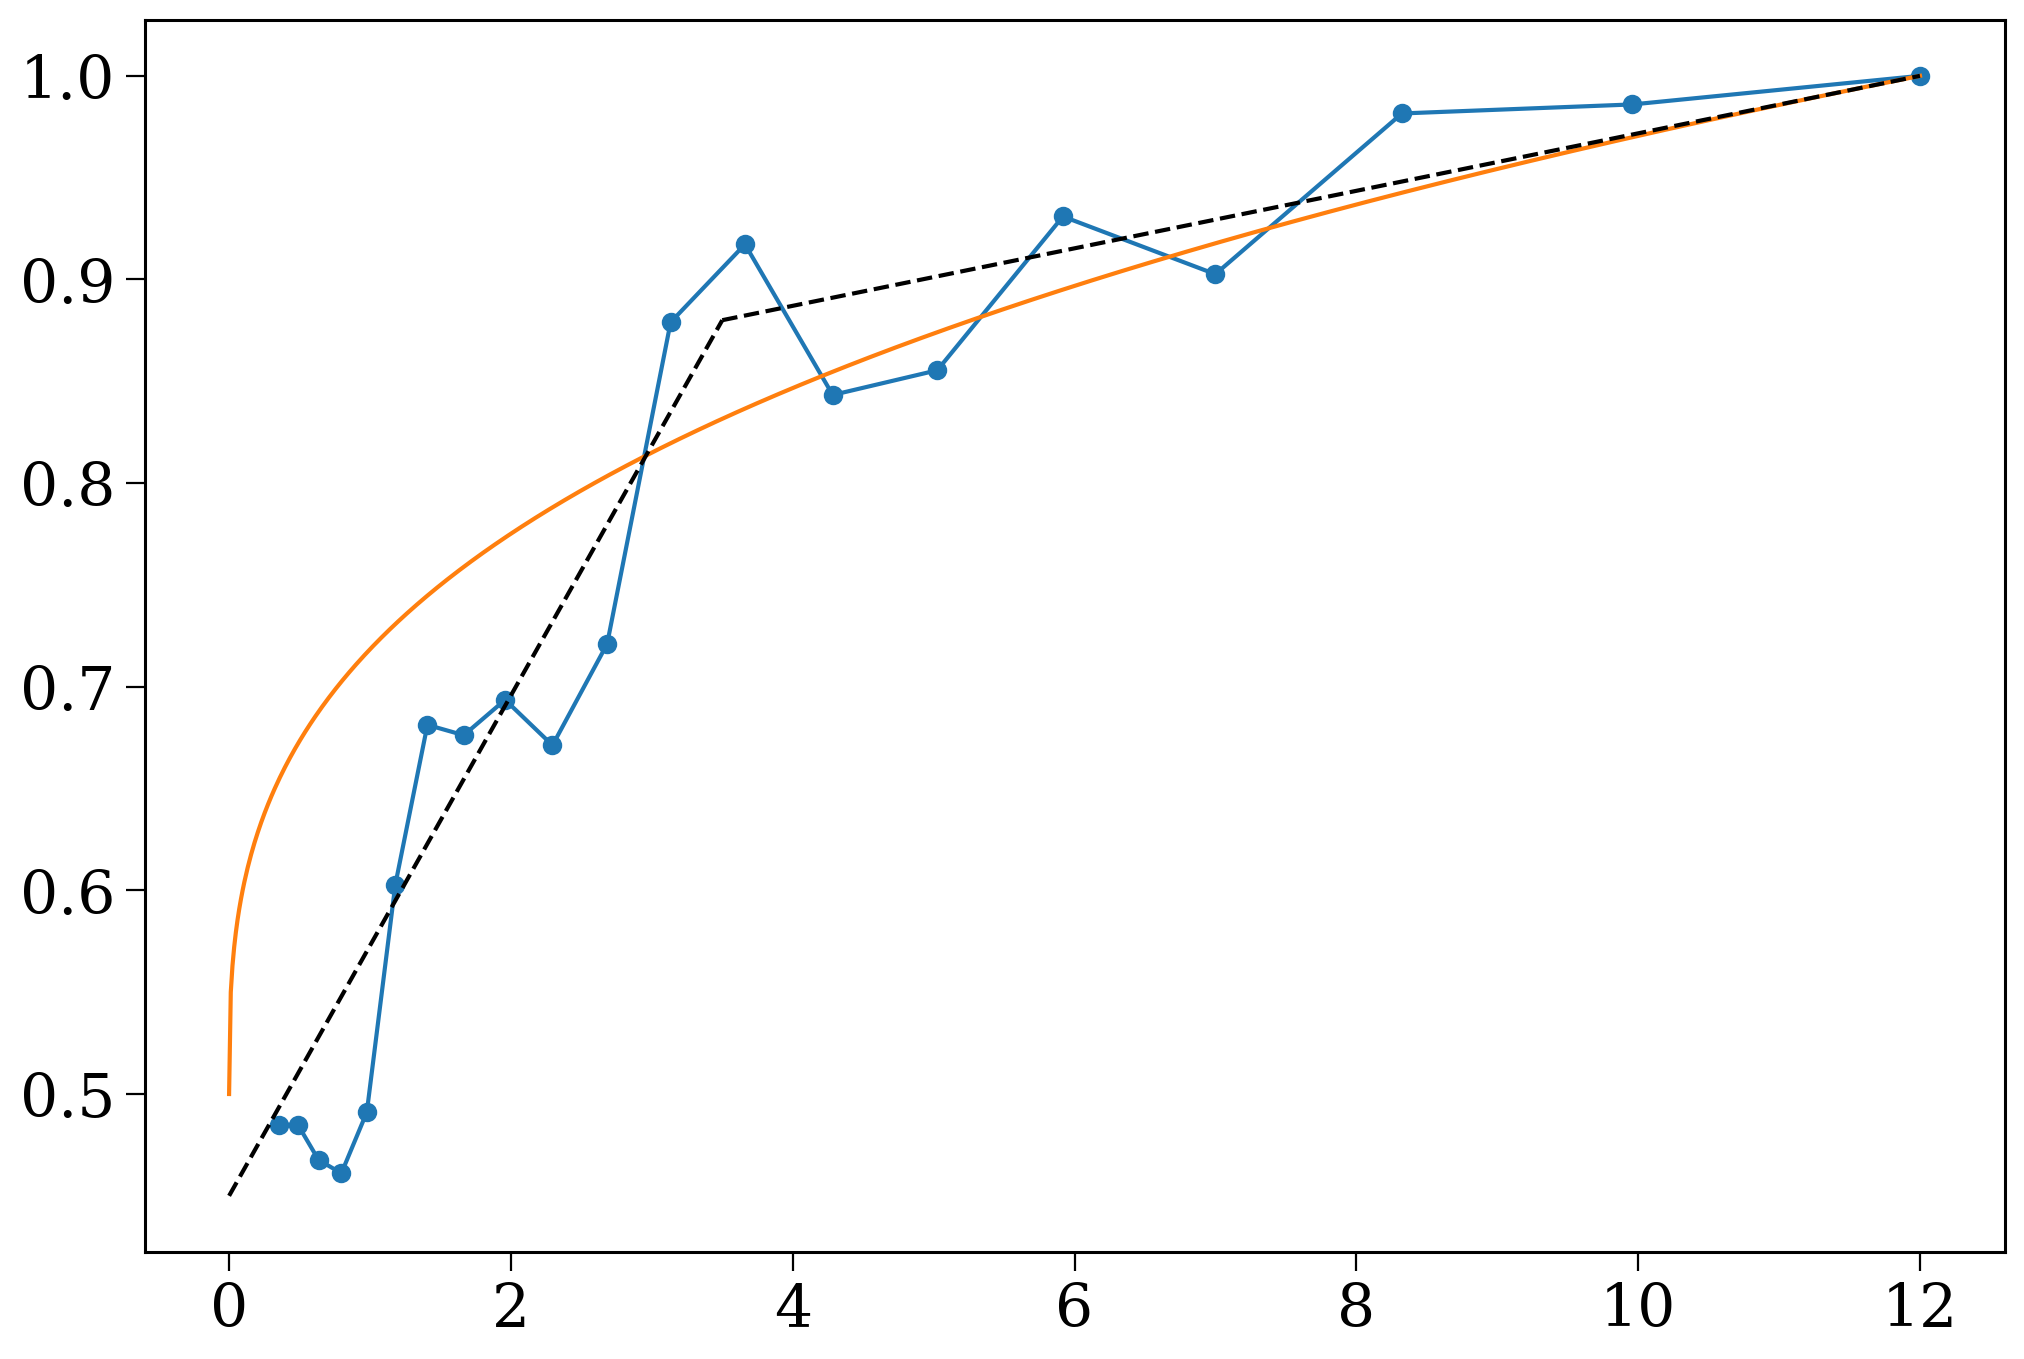

In [45]:
times = cosmo.lookback_time(redshifts).to(u.Gyr)
t_range = np.linspace(0, 12, 1000)
plt.plot(12 * u.Gyr - times, M_at_r / M_at_r.max(), marker='o')

powerlaw = 1/3
plt.plot(t_range, 0.5 + 0.5 * t_range**powerlaw / t_range[-1]**powerlaw)

plt.plot([0, 3.5], [0.45, 0.88], color='k', linestyle='--')
plt.plot([3.5, 12], [0.88, 1.0], color='k', linestyle='--')

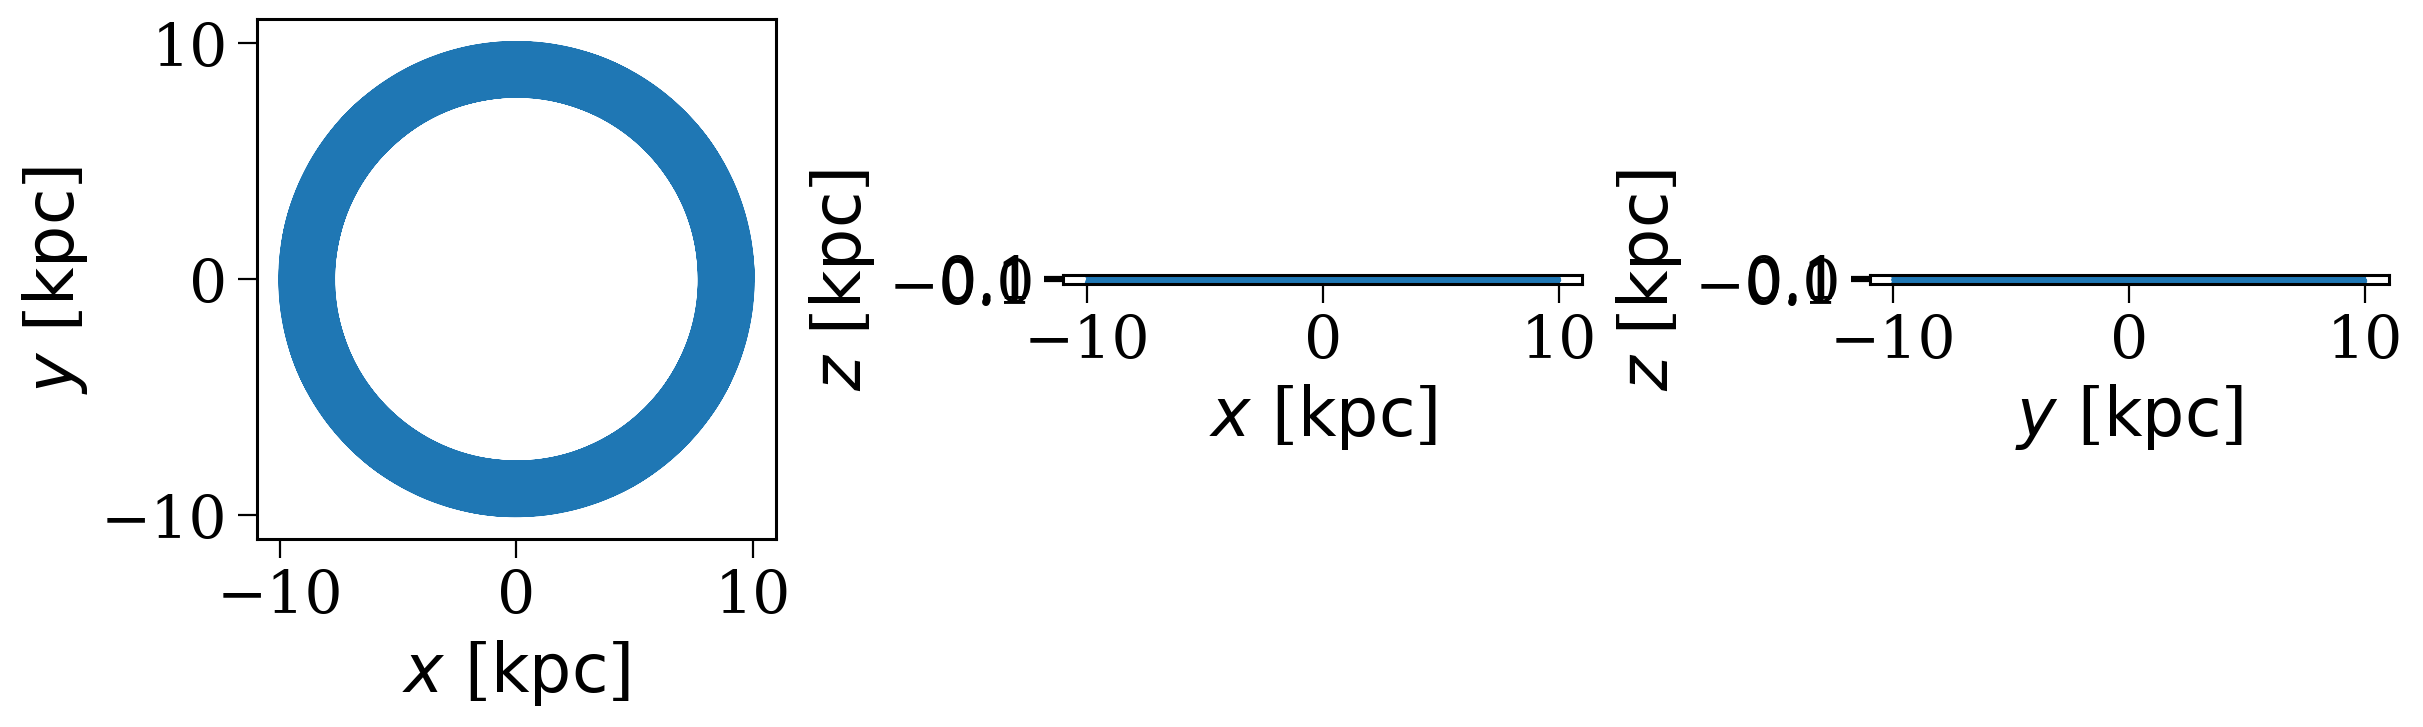

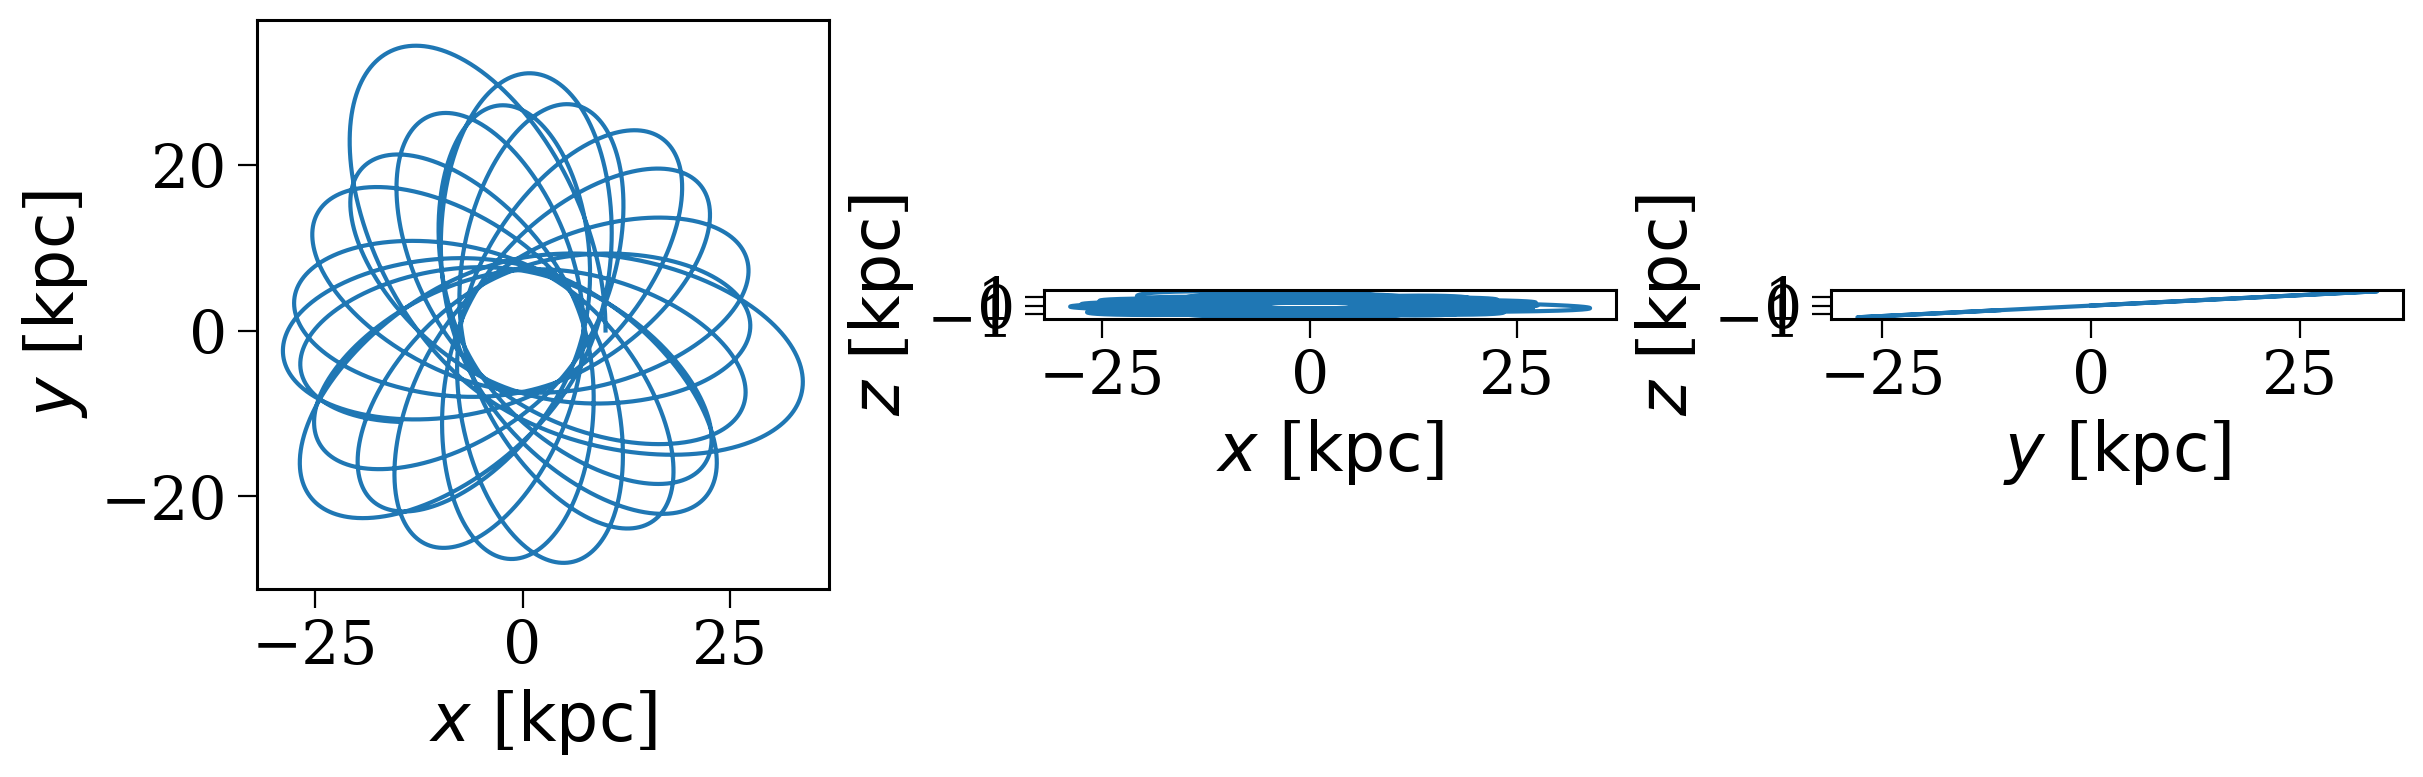

In [48]:
# integrate a test particle orbit in both potentials and compare
import gala.dynamics as gd
w0 = gd.PhaseSpacePosition(pos=[10.0, 0.0, 0.0] * u.kpc, vel=[0, 200.0, 10] * u.km / u.s)
orbit_static = static_mw.integrate_orbit(w0, t1=0, t2=12 * u.Gyr, dt=1 * u.Myr)
orbit_evolving = evolving_mw.integrate_orbit(w0, t1=0, t2=12 * u.Gyr, dt=1 * u.Myr)

orbit_static.plot()
plt.show()
orbit_evolving.plot()
plt.show()

In [49]:
from gala.potential.potential.io import to_dict as potential_to_dict, from_dict as potential_from_dict

In [52]:
potential_from_dict(potential_to_dict(evolving_mw))

<CompositePotential disk,bulge,nucleus,halo>

In [91]:
simple = gp.TimeInterpolatedPotential(
    gp.NFWPotential, time_knots, m=mass_at_knot, r_s=15.63 * u.kpc, units="galactic"
)

In [ ]:
import cogsworth

p = cogsworth.pop.Population(10, use_default_BSE_settings=True, processes=2, galactic_potential=simple)
p.create_population()

Run for 10 binaries
Ended up with 13 binaries with m1 > 0 solar masses
[2e-02s] Sample initial binaries
[0.3s] Evolve binaries (run COSMIC)


100%|██████████| 13/13 [00:00<00:00, 1729.56it/s]Process ForkPoolWorker-12:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/queues.py", line 367, in get
    return _Forking

KeyboardInterrupt: 

  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)


  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/queues.py", line 364, in get
    with self._rlock:
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/queues.py", line 365, in get
    res = self._reader.recv_bytes()
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/connection.py", line 216, in recv_bytes
    buf = self._recv_bytes(maxlength)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^
Keybo

In [84]:

redshift_times = cosmo.lookback_time(redshifts).to(u.Gyr)
plot_times = [12, 10, 8, 6, 4, 2, 0] * u.Gyr
closest_indices = [np.argmin(np.abs(redshift_times - pt)) for pt in plot_times]
closest_indices

[np.int64(0),
 np.int64(8),
 np.int64(13),
 np.int64(15),
 np.int64(17),
 np.int64(18),
 np.int64(19)]

Text(0.5, 0, 'Lookback time [Gyr]')

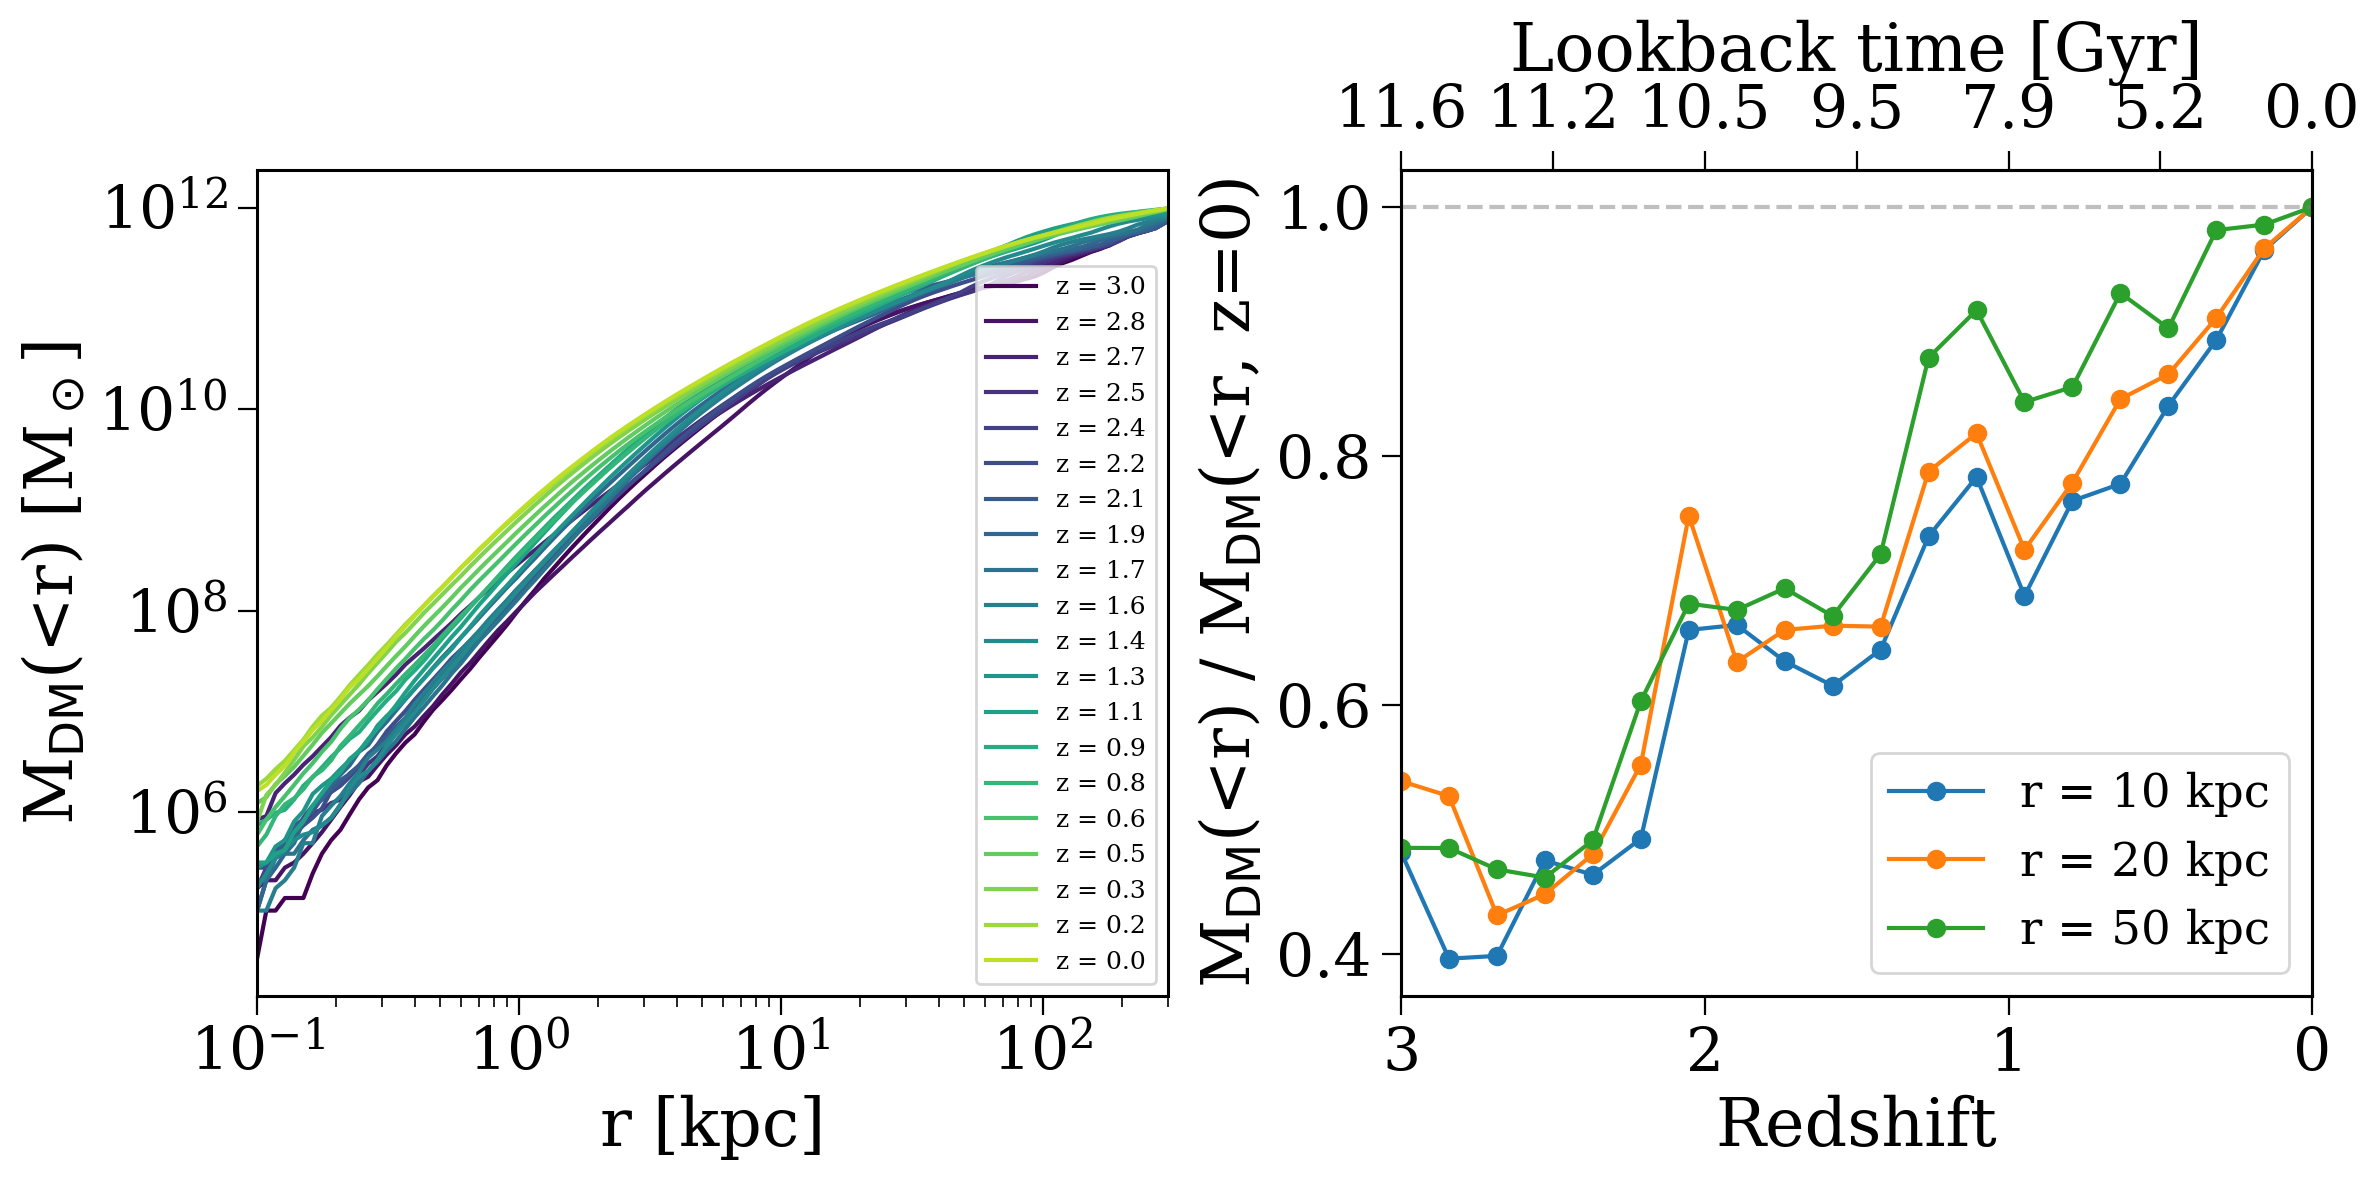

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), layout="tight")

ax = axes[0]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(redshifts)))
for i, z in enumerate(redshifts):
    ax.loglog(r_bins, enclosed_masses[i], color=colors[i], label=f"z = {z:.1f}")
for i, z in enumerate(redshifts):
    ax.loglog(r_bins, enclosed_masses[i], color=colors[i], label=f"z = {z:.1f}")

ax.set_xlabel("r [kpc]")
ax.set_ylabel(r"M$_{\rm DM}$(<r) [M$_\odot$]")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(0.1, 300)

# ---
ax = axes[1]
fixed_radii = [10, 20, 50]
for r_fix in fixed_radii:
    idx = np.argmin(np.abs(r_bins - r_fix))
    M_at_r = enclosed_masses[:, idx]

    # normalize to z=0 value
    ax.plot(redshifts, M_at_r / M_at_r[-1], "o-", label=f"r = {r_fix} kpc")

ax.set_xlabel("Redshift")
ax.set_ylabel(r"M$_{\rm DM}$(<r) / M$_{\rm DM}$(<r, z=0)")
ax.legend(loc="lower right")
ax.set_xlim(3, 0)
ax.axhline(1, color="gray", ls="--", alpha=0.5)

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())

z_ticks = np.arange(3, 0 - 1e-3, -0.5)
t_labels = [f"{cosmo.lookback_time(z).to(u.Gyr).value:.1f}" for z in z_ticks]
ax_top.set_xticks(z_ticks)
ax_top.set_xticklabels(t_labels)
ax_top.set_xlabel("Lookback time [Gyr]")

ValueError: x and y must have same first dimension, but have shapes (8,) and (20,)

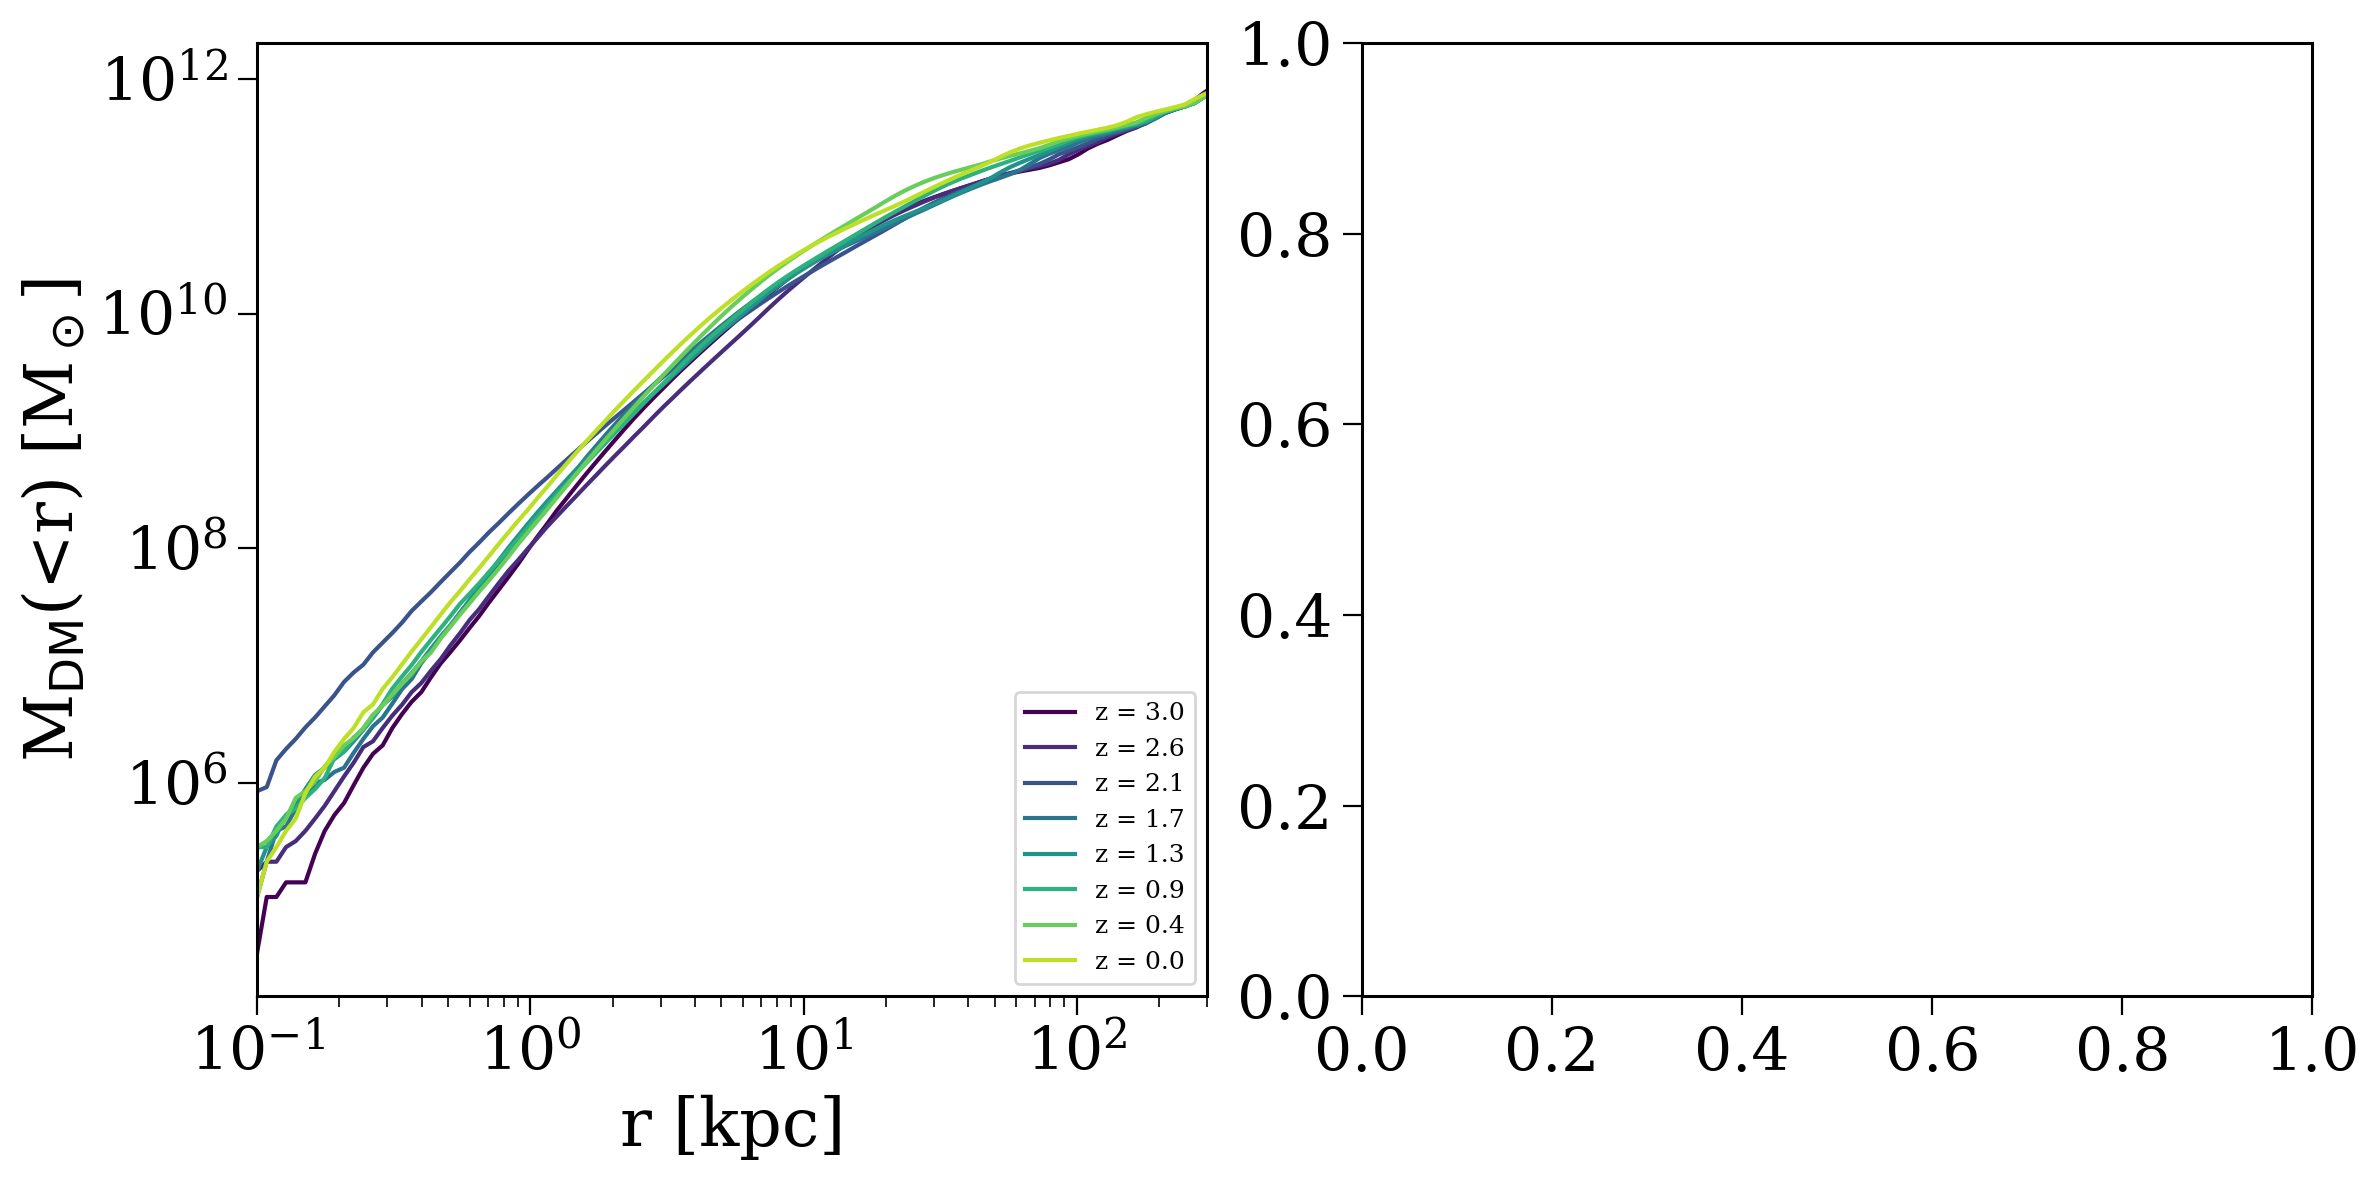

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), layout="tight")

ax = axes[0]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(redshifts)))
for i, z in enumerate(redshifts):
    ax.loglog(r_bins, enclosed_masses[i], color=colors[i], label=f"z = {z:.1f}")

ax.set_xlabel("r [kpc]")
ax.set_ylabel(r"M$_{\rm DM}$(<r) [M$_\odot$]")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(0.1, 300)

# ---
ax = axes[1]
fixed_radii = [10, 20, 50]
for r_fix in fixed_radii:
    idx = np.argmin(np.abs(r_bins - r_fix))
    M_at_r = enclosed_masses[:, idx]

    # normalize to z=0 value
    ax.plot(redshifts, M_at_r / M_at_r[-1], "o-", label=f"r = {r_fix} kpc")

ax.set_xlabel("Redshift")
ax.set_ylabel(r"M$_{\rm DM}$(<r) / M$_{\rm DM}$(<r, z=0)")
ax.legend(loc="lower right")
ax.set_xlim(3, 0)
ax.axhline(1, color="gray", ls="--", alpha=0.5)

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())

z_ticks = np.arange(3, 0 - 1e-3, -0.5)
t_labels = [f"{cosmo.lookback_time(z).to(u.Gyr).value:.1f}" for z in z_ticks]
ax_top.set_xticks(z_ticks)
ax_top.set_xticklabels(t_labels)
ax_top.set_xlabel("Lookback time [Gyr]")